# Load all imports  

In [ ]:
# Base import 
import torch 
from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset
import torchvision.transforms as transforms
import numpy as np 
from tqdm import tqdm 
import random
import matplotlib.pyplot as plt 
import cv2
import networkx as nx 
import pandas as pd
import copy 
#import shap

# Load the base DIFFLOGIC functions
import DiffLogicMnist as difflog
from DiffLogicMnist import os, initialize, compose, Model, LogicLayer

# Load the base DIFFLOGIC functions
# import LogicGraph as LogicGraph

# Load the class-specific datasets (and for TN, TP, FN, FP)
import subset_loaders as subset

# Dataset imports
import mnist_dataset
ALL_OPERATIONS = [
    "zero", "and", "not_implies", "a", "not_implied_by", "b", "xor", "or", 
    "not_or", "not_xor", "not_b", "implied_by", "not_a", "implies", "not_and", "one"]


In [2]:
torch.cuda.is_available()

True

# Load full dataset

In [15]:
# Fix random seeds for reproducibility
torch.manual_seed(42)            
torch.cuda.manual_seed(42)        
np.random.seed(42) 

# If using CUDA:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

batch_size = 256 # this can be tuned as well
binarize   = True  # Set this to True if you want to binarize the images
threshold  = 0.5  # Set the threshold for binarization

# Load the full datasets
train_dataset = mnist_dataset.MNIST('./data-mnist', train=True, download=True, remove_border=True)
test_dataset  = mnist_dataset.MNIST('./data-mnist', train=False, remove_border=True)

# Create full dataset loaders
train_dataset = subset.BinarizedDataset(train_dataset, binarize, threshold)
test_dataset  = subset.BinarizedDataset(test_dataset, binarize, threshold)

# Create full dataset loaders
train_loader  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)
test_loader   = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True, drop_last=True)


# Load the model 

In [ ]:
import os 
trained_models_dir = './../../../../mkunzlermaldaner/project/DIFFLOGIC/trained_binary_models'

os.listdir(trained_models_dir)

In [16]:
model_name         = 'binarized_model_077'
model_name_config  = "model_077" # from mnist_config.yaml
model_name_weights = f'{model_name}_weights' # trained weights in model_name.pth
trained_models_dir = './../../../../mkunzlermaldaner/project/DIFFLOGIC/trained_binary_models'
PATH               = f'{trained_models_dir}/{model_name_weights}.pth'

# ensure you have a "mnist_config.yaml" file within a "config" folder
with initialize(version_base=None, config_path="'./../../../../../mkunzlermaldaner/project/DIFFLOGIC/config", job_name="test_app"):
    cfg = compose(config_name="mnist_config_20x20")

# access the configuration for a specific model (e.g., model_000)
model_cfg = cfg['models'][model_name_config]

# instantiate the model and load its weights
model = Model(model_cfg).to('cuda')
model.load(PATH,eval=False)

print(model)
#model.get_accuracy(test_loader)


LogicLayer(400, 2500, train)
LogicLayer(2500, 2500, train)
Model(
  (diff_logic_model): DiffLogic(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (logic_layers): Sequential(
      (0): LogicLayer(400, 2500, train)
      (1): LogicLayer(2500, 2500, train)
    )
    (group): GroupSum(k=10, tau=10)
  )
  (criterion): CrossEntropyLoss()
)


# Convert DiffLogic to LogicGraph 

In [4]:
from LogicGraph import * 
    
print("Creating LogicGraph")
gall = LogicGraph(model.diff_logic_model)

#print("Computing SF")
gall.compute_sf(train_loader)
gall.compute_sp(np.ones((20,20))-0.5)

Creating LogicGraph


Processing MNIST images: 100%|██████████| 234/234 [00:23<00:00,  9.99it/s]


In [6]:
gall.compute_sf(train_loader)


Processing MNIST images: 100%|██████████| 234/234 [00:23<00:00,  9.82it/s]


In [ ]:
print("Computing SF")
gall.compute_sp(np.ones((20,20))-0.5)

In [ ]:
gall.edges()[('L1_N2029', 'L2_N2124')]["ab"]

# Difference of SP for Individual Classes 

### Find the TP, TN, FP, FN instances, and use this to create sub-datasets for specific cases 

In [5]:
saved = True 

def predict_and_categorize(model, data_loader, binarize=False, threshold=0.5):
    all_images = []
    all_labels = []
    all_predictions = []

    # Ensure model is in evaluation mode
    model.diff_logic_model.eval()

    with torch.no_grad():  # Disable gradient calculation for inference
        for batch_inputs, batch_outputs in tqdm(data_loader, desc="Predicting"):
            batch_inputs, batch_outputs = batch_inputs.to('cuda'), batch_outputs.to('cuda')

            if binarize:
                batch_inputs = (batch_inputs > threshold).float()

            # Forward pass to get predictions
            outputs = model.diff_logic_model(batch_inputs)

            # Get the predicted class (index of the maximum logit)
            _, predicted = torch.max(outputs.data, 1)

            all_images.append(batch_inputs.cpu())
            all_labels.append(batch_outputs.cpu())
            all_predictions.append(predicted.cpu())

    all_images = torch.cat(all_images)
    all_labels = torch.cat(all_labels)
    all_predictions = torch.cat(all_predictions)

    return all_images, all_labels, all_predictions

if not saved: 
    # Usage:
    binarize = True  # Set to True if you want to binarize the images
    threshold = 0.5  # Set the threshold for binarization if binarize is True

    all_images_train, all_labels_train, all_predictions_train = predict_and_categorize(model, train_loader, binarize=binarize, threshold=threshold)
    all_images_test,  all_labels_test,  all_predictions_test  = predict_and_categorize(model,  test_loader, binarize=binarize, threshold=threshold) 

    torch.save(     all_images_train, './datasets/all_images_train.pth')
    torch.save(     all_labels_train, './datasets/all_labels_train.pth')
    torch.save(all_predictions_train, './datasets/all_predictions_train.pth')

    torch.save(     all_images_test, './datasets/all_images_test.pth')
    torch.save(     all_labels_test, './datasets/all_labels_test.pth')
    torch.save(all_predictions_test, './datasets/all_predictions_test.pth')

else: 
    all_images_train      = torch.load('./datasets/all_images_train.pth')
    all_labels_train      = torch.load('./datasets/all_labels_train.pth')
    all_predictions_train = torch.load('./datasets/all_predictions_train.pth')

    all_images_test       = torch.load('./datasets/all_images_test.pth')
    all_labels_test       = torch.load('./datasets/all_labels_test.pth')
    all_predictions_test  = torch.load('./datasets/all_predictions_test.pth')

if not saved: 
    # Fix random seeds for reproducibility
    torch.manual_seed(42)            
    torch.cuda.manual_seed(42)        
    np.random.seed(42)
    # If using CUDA:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Init parameters
    batch_size = 256   # this can be tuned as well 
    binarize   = True  # Set this to True if you want to binarize the images
    threshold  = 0.5   # Set the threshold for binarization

    # Create class-specific data loaders for training and testing sets
    train_class_loaders = subset.create_class_dataloaders(train_dataset, batch_size, binarize=binarize, threshold=threshold)
    test_class_loaders  = subset.create_class_dataloaders(test_dataset,  batch_size, binarize=binarize, threshold=threshold)

    print("Saving the Class Datasets")
    torch.save(train_class_loaders, './datasets/train_class_loaders.pth')
    torch.save(test_class_loaders, './datasets/test_class_loaders.pth')

    # Create TN/TP/FN/FP datasets
    general_datasets        = subset.create_tn_tp_fn_fp_datasets(all_images_train, all_labels_train, all_predictions_train)
    class_specific_datasets = subset.create_class_specific_datasets(all_images_train, all_labels_train, all_predictions_train)

    print("Saving the General Datasets")
    torch.save(general_datasets, './datasets/general_datasets.pth')

    # For the general TN, TP, FN, FP datasets:
    t_dataset = DataLoader(general_datasets['T'],batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)
    f_dataset = DataLoader(general_datasets['F'],batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)

    print("Saving the General Datasets")
    torch.save(t_dataset, './datasets/t_dataset.pth')
    torch.save(f_dataset, './datasets/f_dataset.pth')

    # For class-specific datasets (e.g., for class 5):
    print("Saving the Class-Specific Datasets")
    for i in range(10): 
        class_specific_datasets['TP_class'][i] = DataLoader(class_specific_datasets['TP_class'][i],batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)
        class_specific_datasets['FP_class'][i] = DataLoader(class_specific_datasets['FP_class'][i],batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)
        class_specific_datasets['TN_class'][i] = DataLoader(class_specific_datasets['TN_class'][i],batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)
        class_specific_datasets['FN_class'][i] = DataLoader(class_specific_datasets['FN_class'][i],batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)

    torch.save(class_specific_datasets, './datasets/class_specific_datasets.pth')    
else: 
    t_dataset               = torch.load('./datasets/t_dataset.pth')
    f_dataset               = torch.load('./datasets/f_dataset.pth')
    class_specific_datasets = torch.load('./datasets/class_specific_datasets.pth')
    train_class_loaders     = torch.load('./datasets/train_class_loaders.pth')
    test_class_loaders      = torch.load('./datasets/test_class_loaders.pth')
    general_datasets        = torch.load('./datasets/general_datasets.pth')
    

# Compute the Class-Specific Differences

In [6]:
outputs = [f"L3_N0", f"L3_N1", f"L3_N2", f"L3_N3", f"L3_N4", f"L3_N5", f"L3_N6", f"L3_N7", f"L3_N8", f"L3_N9"]

p_maps = []
sp_graphs = [] 
sp_diffs = [] 
for j, output_node in enumerate(outputs): 
    p_maps.append(cv2.imread(f"mnist_averages/average_digit_{j}.png")[4:24,4:24,1]/255)
    sp_graph  = copy.deepcopy(gall)
    sp_graph.compute_sp(p_maps[j])
    sp_graphs.append(sp_graph)
    sp_diffs.append(sp_graph.sub_sp(gall))

In [7]:
# Compute SF for each graph
graphs = {}
for g in range(10): 
    print(f"Class {g}")
    graphs[g] = LogicGraph(model.diff_logic_model)
    graphs[g].compute_sf(train_class_loaders[g])


Class 0


Processing MNIST images: 100%|██████████| 23/23 [00:02<00:00,  9.63it/s]


Class 1


Processing MNIST images: 100%|██████████| 26/26 [00:02<00:00,  9.84it/s]


Class 2


...

Processing MNIST images: 100%|██████████| 24/24 [00:02<00:00, 10.24it/s]


Class 8


Processing MNIST images: 100%|██████████| 22/22 [00:02<00:00, 10.28it/s]


Class 9


Processing MNIST images: 100%|██████████| 23/23 [00:02<00:00,  9.27it/s]


In [8]:
# Compute SF for each graph
fps = {}
tps = {}
fns = {}
tns = {}
for g in range(10): 
    print(g)
    fps[g] = LogicGraph(model.diff_logic_model)
    if [i for i in class_specific_datasets['FP_class'][g]] != []:
        fps[g].compute_sf(class_specific_datasets['FP_class'][g])
    #tps[g] = LogicGraph(model.diff_logic_model)
    #if [i for i in class_specific_datasets['TP_class'][g]] != []:
    #    tps[g].compute_sf(class_specific_datasets['TP_class'][g])
    fns[g] = LogicGraph(model.diff_logic_model)
    if [i for i in class_specific_datasets['FN_class'][g]] != []:
        fns[g].compute_sf(class_specific_datasets['FN_class'][g])
    tns[g] = LogicGraph(model.diff_logic_model)
    if [i for i in class_specific_datasets['TN_class'][g]] != []:
        tns[g].compute_sf(class_specific_datasets['TN_class'][g])


0


Processing MNIST images: 100%|██████████| 209/209 [00:10<00:00, 20.16it/s]


1


Processing MNIST images: 100%|██████████| 205/205 [00:10<00:00, 20.04it/s]


2


...

Processing MNIST images: 100%|██████████| 207/207 [00:10<00:00, 19.89it/s]


8


Processing MNIST images: 100%|██████████| 209/209 [00:10<00:00, 19.87it/s]


9


Processing MNIST images: 100%|██████████| 208/208 [00:10<00:00, 19.86it/s]


In [9]:
# Compute SF Diff for each combination
print("Computing diffs")
diffs = {}
for i in range(10): 
    diff = {} 
    for j in range(10): 
        diff[j] = graphs[i] - graphs[j]
    diffs[i] = diff

print("Computing centered")
centered = {}
for i in range(10): 
    centered[i] = graphs[i] - gall
    
print("Computing specific")
specific = {}
for i in range(10): 
    specific[i] = graphs[i] - tns[i]    

Computing diffs
Computing centered
Computing specific


# Plot the Differences in the switching frequency per Class Prediction

In [ ]:
fig, ax = plt.subplots(10,10,figsize=(10,10))
for i in range(10): 
    for j in range(10): 
        sf = list(nx.get_node_attributes(diffs[i][j].g,"sf").values())
        ax[i][j].hist(sf,bins=20)

# Initialize helper functions for visualizing the FAN-IN

In [10]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

a_not_list = ["not_implied_by", "not_or","not_xor","not_a","implies","not_and"]
b_not_list = ["not_implies", "not_or","not_xor","not_b","implied_by","not_and"]

#def find_fan_in(G, output_node, threshold):
#    """
#    Find all input nodes connected to the given output node.
#    """
#    fan_in = set()
#    nodes_to_check = [(output_node,1)]
#    pixels = []
#    while nodes_to_check:
#        
#        current_node, psign = nodes_to_check.pop(0)
#        preds = []
#        preds_extend = []
#        gtype = G.nodes[current_node]["gate"]
#        for node in list(G.predecessors(current_node)): 
#            
#            new_psign = psign*1
#            
#            # Determine whether the current gate/input activates the class when 0 or 1
#            props = G.get_edge_data(node, current_node)
#            etype = props["ab"] if "ab" in props.keys() else None
#            if (etype == "a" and gtype in a_not_list) or (etype == "b" and gtype in b_not_list): 
#                new_psign=-1*new_psign
#            
#            comparitor = threshold
#            if new_psign == -1: 
#                comparitor = 1 - threshold
#            
#            if "sf" in G.nodes[node].keys() and G.nodes[node]["sf"] > comparitor: 
#                
#                preds_extend.append((node,new_psign))
#                preds.append((node,new_psign))
#                
#            else: 
#
#                preds.append((node,new_psign))
#                pixels.append((node,new_psign))
#        
#        fan_in.update(preds)
#        nodes_to_check.extend(preds_extend)
#
#    return fan_in, pixels


def find_fan_in(G, output_node, threshold,metric="sf"):
    """
    Find all input nodes connected to the given output node.
    """
    fan_in = set()
    nodes_to_check = [(output_node,1)]
    input_set = []
    while nodes_to_check:
        
        # Get node and node properties 
        parent_node, dpo = nodes_to_check.pop(0)
        new_fan_in  = []
        child_gates = []
        parent_type = G.nodes[parent_node]["gate"]
        
        # Account for all predesesors
        for child_node in list(G.predecessors(parent_node)): 
            
            desired_parent_output = dpo*1
            
            # Get type of child node 
            child_type = G.nodes[child_node]["gate"]
            
            # Account for output case 
            if parent_type == "output": 

                # Check whether the current node is contributing to the class output
                desired_child_output = desired_parent_output
                if G.nodes[child_node][metric] > threshold: 
                    child_gates.append((child_node, desired_child_output))
                    new_fan_in.append((child_node,  desired_child_output))

            # Account for hidden-layer case 
            elif child_node != "input": 

                # Get the current wire type
                props     = G.get_edge_data(child_node, parent_node)
                wire_type = props["ab"] if "ab" in props.keys() else None

                # Check whether the current wire increases the class score by being zero
                if (wire_type == "a" and parent_type in a_not_list) or (wire_type == "b" and parent_type in b_not_list): 
                    
                    # Adjust the "desired child output"
                    desired_child_output = -desired_parent_output
                    
                    # Check whether the current node is contributing to the class output
                    if G.nodes[child_node][metric] <= threshold: # Less than because we contribute by being a zero 
                        child_gates.append((child_node,desired_child_output))
                        new_fan_in.append((child_node,desired_child_output))
                    
                # Case where the current wire increases the class score by being a one
                else: 
                    
                    # Adjust the "desired child output"
                    desired_child_output = desired_parent_output
                    
                    # Check whether the current node is contributing to the class output
                    if G.nodes[child_node][metric] > threshold: 
                        child_gates.append((child_node,desired_child_output))
                        new_fan_in.append((child_node,desired_child_output))

            # Account for input case
            else: 
                
                # Get the current wire type
                props = G.get_edge_data(child_node, parent_node)
                wire_type = props["ab"] if "ab" in props.keys() else None

                # Check whether the current wire increases the class score by being zero
                if (wire_type == "a" and parent_type in a_not_list) or (wire_type == "b" and parent_type in b_not_list): 
                    
                    # Adjust the "desired child output"
                    child_sign = -1*parent_sign
                    new_fan_in.append(  (child_node, child_sign))
                    input_set.append( (child_node, child_sign))
                    
                # Case where the current wire increases the class score by being a one
                else: 
                    
                    # Adjust the "desired child output"
                    child_sign = parent_sign
                    new_fan_in.append(  (child_node, child_sign))
                    input_set.append( (child_node, child_sign))
                        
        fan_in.update(new_fan_in)
        nodes_to_check.extend(child_gates)

    return fan_in, input_set

def node_to_pixel(node_id):
    """
    Convert a node ID (e.g., 'L0_Gate 1') to pixel coordinates.
    Assumes the input layer corresponds to a 28x28 image (MNIST format).
    """
    if (node_id != "HIGH") and (node_id != "LOW"): 
        layer, gate = node_id.split('_')
        
        gate_num = int(gate.split("N")[1]) - 1  # Convert 'Gate X' to zero-based index

        if layer == 'L0':  # Input layer
            y = gate_num // 20
            x = gate_num % 20
            return (x, y)
        
    return None  # For non-input layers, return None

def visualize_fan_in(G, output_node,threshold,signed=True, show=False,metric="sf"):
    """
    Visualize the fan-in of the given output node as highlighted pixels in an image.
    """
    fan_in,pixels = find_fan_in(G, output_node,threshold,metric)
    # Create a blank 28x28 image
    img = np.zeros((20, 20))
    
    # Highlight pixels corresponding to input nodes in the fan-in
    for node,sign in fan_in:
        pixel = node_to_pixel(node)
        if pixel:
            x, y = pixel
            if signed: 
                img[y, x] += sign  # Set pixel to white (1)
            else: 
                img[y, x] += 1  # Set pixel to white (1)

    if show: 
        # Plot the image
        plt.imshow(img)
        plt.title(f"Fan-in visualization for {output_node}")
        plt.colorbar()
        plt.axis('off')
        plt.show()
    
    return img, fan_in,pixels


# Visualize the saliency maps for the FAN-IN (Class specific SF, and Global SF)

In [ ]:
gall.compute_sf(train_loader)

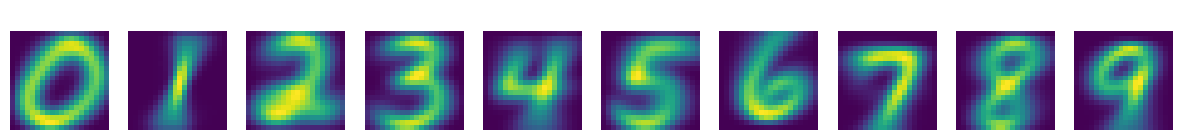

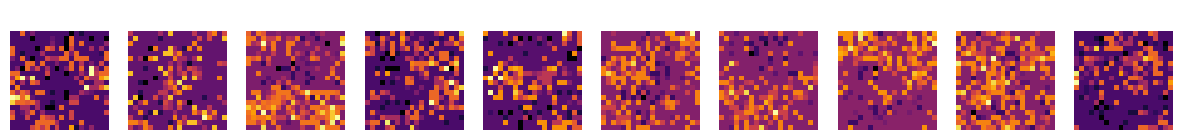

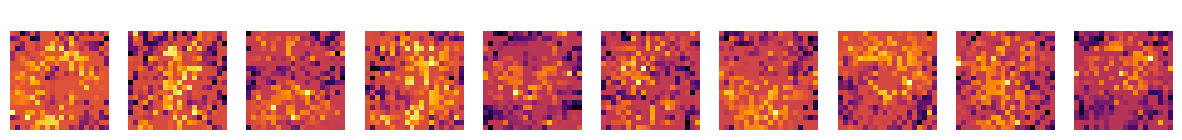

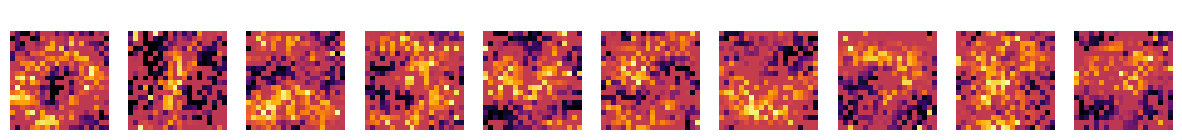

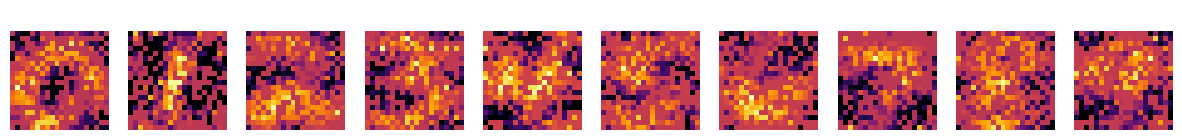

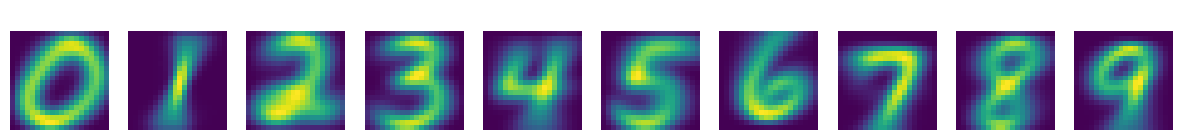

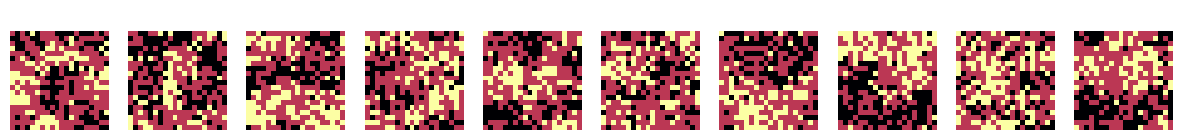

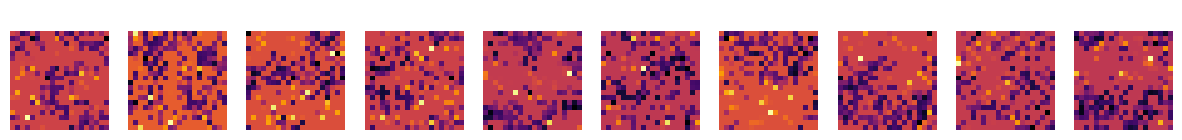

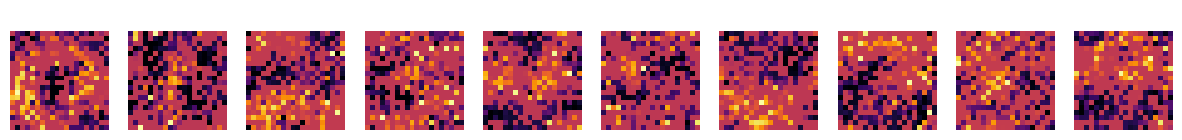

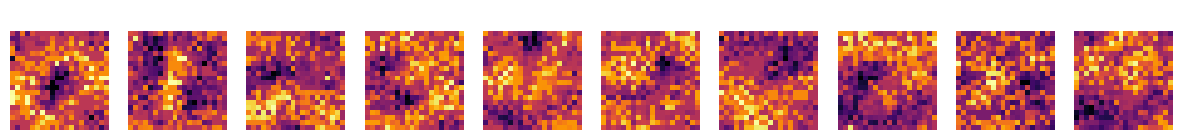

In [11]:
thresholds = [float(i)/100-1.0 for i in range(200)]
#thresholds = [0.0]
outputs = [f"L3_N0", f"L3_N1", f"L3_N2", f"L3_N3", f"L3_N4", f"L3_N5", f"L3_N6", f"L3_N7", f"L3_N8", f"L3_N9"]
test = False


def plot_row(g,thresholds,signed,metric): 
    # Plot pixel attribution  
    fig, ax = plt.subplots(1, len(outputs), figsize=(15, 10))
    for i, output_node in enumerate(outputs): 
        G = g[i].g
        im = []
        for threshold in thresholds: 
            img, fan_in,pixels = visualize_fan_in(G, output_node, threshold,signed, False,metric)
            im.append(img)
        img  = np.average(im,axis=0)
        ax[i].imshow(img,cmap="inferno")
        ax[i].title.set_text(" ")#(f"{i}")
        ax[i].set_axis_off()
    plt.show()
    
print("#################################################### MNIST ####################################################")if test else None 
import copy 
fig, ax = plt.subplots(1, len(outputs), figsize=(15, 10))
p_maps = []
sp_graphs = [] 
sp_diffs = [] 
for j, output_node in enumerate(outputs): 
    p_maps.append(cv2.imread(f"mnist_averages/average_digit_{j}.png")[4:24,4:24,1]/255)
    sp_graph  = copy.deepcopy(gall)
    sp_graph.compute_sp(p_maps[j])
    sp_graphs.append(sp_graph)
    sp_diffs.append(sp_graph.sub_sp(gall))
    ax[j].imshow(p_maps[j])
    ax[j].title.set_text(" ")#(f"{j}")
    ax[j].set_axis_off()
plt.show()
#burn = cv2.imread(f"mnist_averages/average_all_digits.png")
#ax[len(outputs)].imshow(burn[4:24,4:24,1])


t1 = [float(i)/100 for i in range(100)]
t2 = [float(i)/100-0.5 for i in range(100)]


print("#################################################### Switch Probability ####################################################")if test else None 

print("--- Uniform 0.5") if test else None 
gall.compute_sp(np.ones((20,20))-0.5)
plot_row([gall for i in range(len(graphs))],t1,True,"sp")

print("--- Average of All MNIST Digits") if test else None 
p_maps.append(cv2.imread(f"mnist_averages/average_all_digits.png")[4:24,4:24,1]/255)
gall.compute_sp(p_maps[-1])
plot_row([gall for i in range(len(graphs))],t1,True,"sp")

print("--- Average of Class-Specific MNIST Digits") if test else None 
plot_row(sp_graphs,t1,True,"sp")

print("--- (Class-Specific-Average) - (Global-Average)") if test else None 
plot_row(sp_diffs,t2,True,"sp")

print("#################################################### Switch Frequency ####################################################")if test else None 

fig, ax = plt.subplots(1, len(outputs), figsize=(15, 10))
p_maps = []
sp_graphs = [] 
sp_diffs = [] 
for j, output_node in enumerate(outputs): 
    p_maps.append(cv2.imread(f"mnist_averages/average_digit_{j}.png")[4:24,4:24,1]/255)
    sp_graph  = copy.deepcopy(gall)
    sp_graph.compute_sp(p_maps[j])
    sp_graphs.append(sp_graph)
    sp_diffs.append(sp_graph.sub_sp(gall))
    ax[j].imshow(p_maps[j])
    ax[j].title.set_text(" ")#(f"{j}")
    ax[j].set_axis_off()
plt.show()

#print("--- Raw Association") if test else None 
#plot_row(graphs,[-1],False,"sf")

print("--- (Signed Association)") if test else None 
plot_row(graphs,[-1,0],True,"sf")

print("--- (All MNIST)") if test else None 
plot_row([gall for i in range(len(graphs))],t1,True,"sf")

print("--- (Class-Specific)") if test else None 
plot_row(graphs,t1,True,"sf")

print("--- (Class-Specific) - (All MNIST)") if test else None 
plot_row(specific,t2,True,"sf")




# Show and generate local explanations

In [ ]:
test = nx.get_node_attributes(g.g,"sf")
t = [test[i] for i in nx.get_node_attributes(g.g,"sf").keys()]

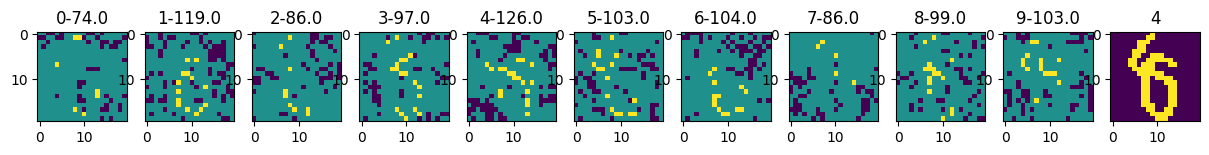

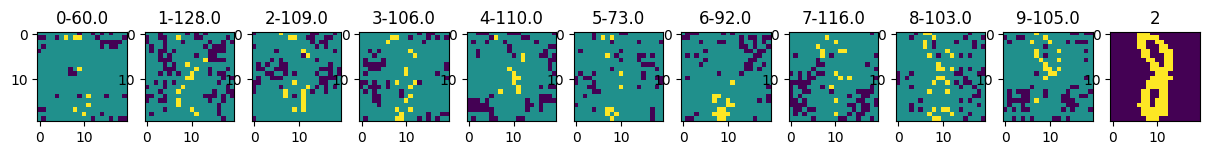

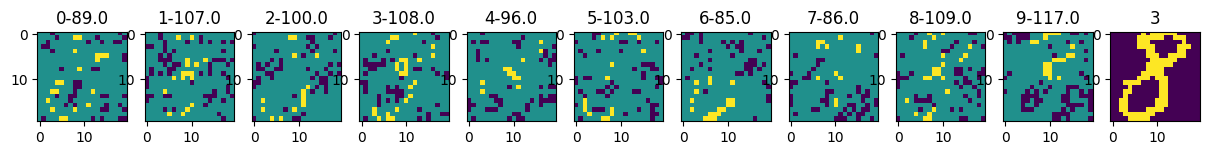

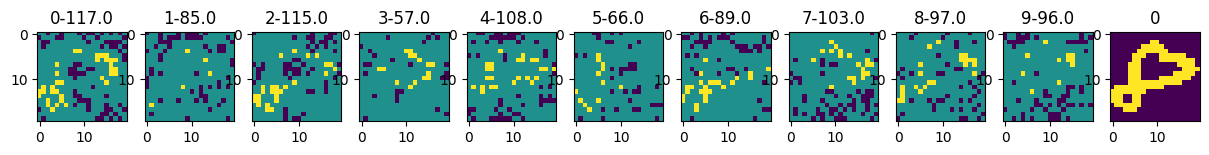

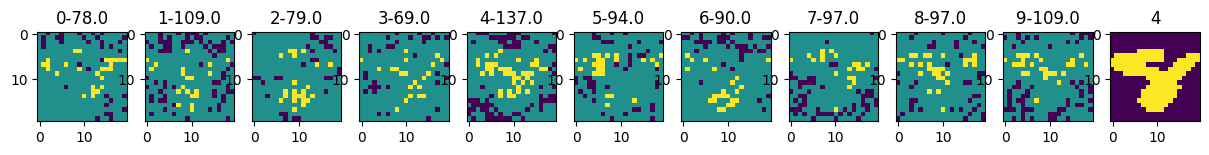

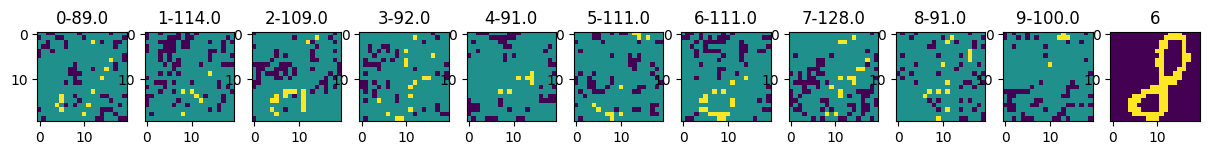

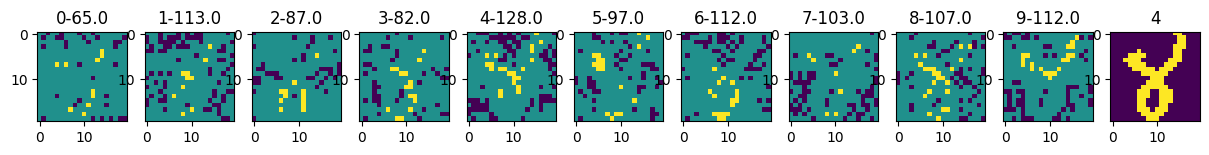

In [12]:

for k,(data,label) in enumerate(class_specific_datasets['FN_class'][8].dataset): 
    g = LogicGraph(model.diff_logic_model)
    g.compute_sf(data)
    
    fig, ax = plt.subplots(1, len(outputs)+1, figsize=(15, 10))
    thresholds = [0.5]
    for i, output_node in enumerate(outputs): 
        im = []
        for threshold in thresholds: 
            img, fan_in,pixels = visualize_fan_in(g.g, output_node, threshold,True,False)
            im.append(img)

        img  = np.average(im,axis=0)
        overlap = np.array(img==(data*2-1).cpu().detach().numpy()).astype(int)
        
        ax[i].imshow((img*overlap).reshape((20,20,1)))
        ax[i].title.set_text(f"{i}-{np.sum(np.abs(img))}")
    ax[len(outputs)].imshow(data.reshape((20,20,1)))
    ax[len(outputs)].title.set_text(f"{np.argmax(np.array(g.forward(data).cpu().detach()))}")
    plt.show()
    
    if k > 5: 
        break 


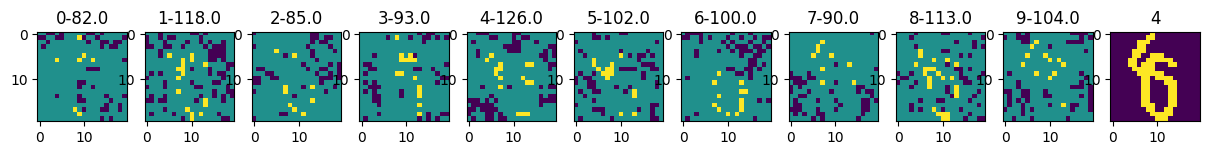

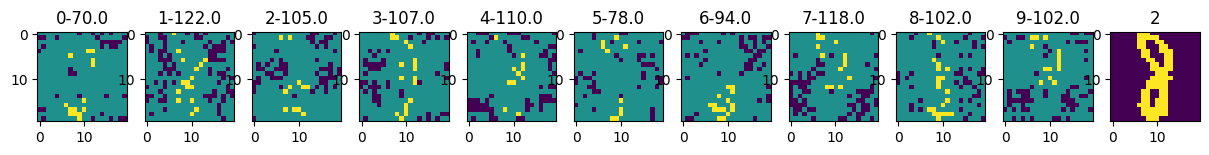

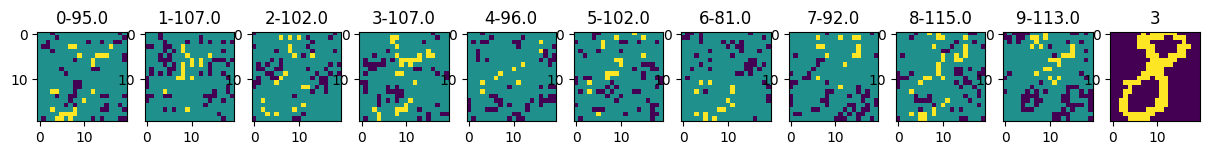

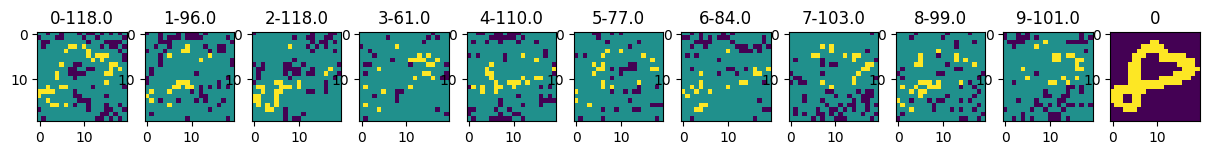

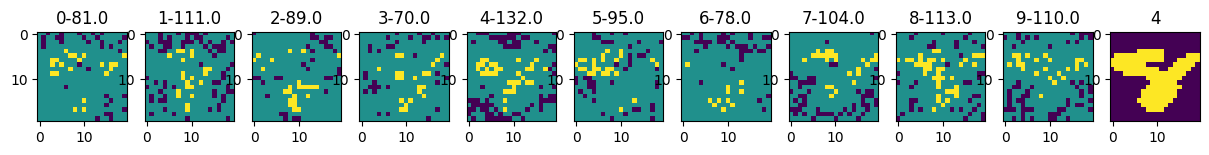

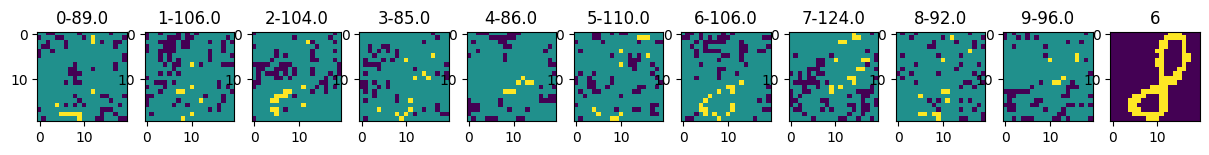

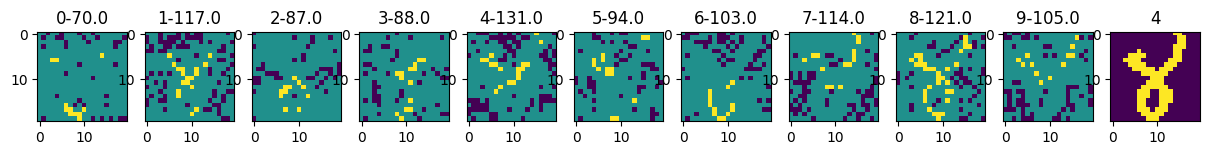

In [82]:

for k,(data,label) in enumerate(class_specific_datasets['FN_class'][8].dataset): 
    g = LogicGraph(model.diff_logic_model)
    g.compute_sp(data)
    
    fig, ax = plt.subplots(1, len(outputs)+1, figsize=(15, 10))
    thresholds = [0]
    for i, output_node in enumerate(outputs): 
        im = []
        for threshold in thresholds: 
            img, fan_in,pixels = visualize_fan_in(g.g, output_node, threshold,True,False,metric="sp")
            im.append(img)

        img  = np.average(im,axis=0)
        overlap = np.array(img==(data*2-1).cpu().detach().numpy()).astype(int)
        
        ax[i].imshow((img*overlap).reshape((20,20,1)))
        ax[i].title.set_text(f"{i}-{np.sum(np.abs(img))}")
    ax[len(outputs)].imshow(data.reshape((20,20,1)))
    ax[len(outputs)].title.set_text(f"{np.argmax(np.array(g.forward(data).cpu().detach()))}")
    plt.show()
    
    if k > 5: 
        break 


In [ ]:
test = True
for k,(data,label) in enumerate(train_loader.dataset): 
    g = LogicGraph(model.diff_logic_model)
    g.compute_sf(data)
    
    fig, ax = plt.subplots(1, len(outputs)+1, figsize=(15, 10))
    thresholds = [0.0]
    for i, output_node in enumerate(outputs): 
        im = []
        for threshold in thresholds: 
            img, fan_in,pixels = visualize_fan_in(g.g, output_node, threshold,True,False,test)
            im.append(img)

        img  = np.average(im,axis=0)
        overlap = np.array(img==(data*2-1).cpu().detach().numpy()).astype(int)
        
        ax[i].imshow((img*overlap).reshape((20,20,1)))
        ax[i].title.set_text(f"{i}-{np.sum(np.abs(img))}")
    ax[len(outputs)].imshow(data.reshape((20,20,1)))
    ax[len(outputs)].title.set_text(f"{np.argmax(np.array(g.forward(data).cpu().detach()))}")
    plt.show()
    
    if k > 5: 
        break 


In [ ]:
class_specific_datasets['FP_class'][index].dataset

In [ ]:
from matplotlib import rc

index = 1

for k,(data,label) in enumerate(class_specific_datasets['TP_class'][index].dataset): 
    g = LogicGraph(model.diff_logic_model)
    g.compute_sf(data)
    
    fig, ax = plt.subplots(1, len(outputs)+1, figsize=(15, 10))
    thresholds = [0.0]
    for i, output_node in enumerate(outputs): 
        im = []
        for threshold in thresholds: 
            img, fan_in,pixels = visualize_fan_in(g.g, output_node, threshold,True,False)
            im.append(img)

        img  = np.average(im,axis=0)
        overlap = np.array(img==(data*2-1).cpu().detach().numpy()).astype(int)
        
        ax[i+1].imshow((img*overlap).reshape((20,20,1)),"inferno",vmin=-1,vmax=1)
        ax[i+1].title.set_text(f"C: {i}; $\Sigma$={int(np.sum(np.abs(img)*overlap))}")
        
        ax[i+1].set_axis_off()
        
    ax[0].imshow(data.reshape((20,20,1)),"inferno")
    ax[0].title.set_text(f"C: {np.argmax(np.array(g.forward(data).cpu().detach()))} (TP)")
    ax[0].set_axis_off()
    plt.show()
    
    break 
        
for k,(data,label) in enumerate(class_specific_datasets['FP_class'][index].dataset): 
    g = LogicGraph(model.diff_logic_model)
    g.compute_sf(data)
    
    fig, ax = plt.subplots(1, len(outputs)+1, figsize=(15, 10))
    thresholds = [0.0]
    for i, output_node in enumerate(outputs): 
        im = []
        for threshold in thresholds: 
            img, fan_in,pixels = visualize_fan_in(g.g, output_node, threshold,True,False)
            im.append(img)

        img  = np.average(im,axis=0)
        overlap = np.array(img==(data*2-1).cpu().detach().numpy()).astype(int)
        
        ax[i+1].imshow((img*overlap).reshape((20,20,1)),"inferno",vmin=-1,vmax=1)
        ax[i+1].title.set_text(f"C: {i}; $\Sigma$={int(np.sum(np.abs(img)*overlap))}")
        
        ax[i+1].set_axis_off()
        
    ax[0].imshow(data.reshape((20,20,1)),"inferno")
    ax[0].title.set_text(f"C: {np.argmax(np.array(g.forward(data).cpu().detach()))} (FP)")
    ax[0].set_axis_off()
    plt.show()
    
    break 
    
        
for k,(data,label) in enumerate(class_specific_datasets['FN_class'][index].dataset): 
    g = LogicGraph(model.diff_logic_model)
    g.compute_sf(data)
    
    fig, ax = plt.subplots(1, len(outputs)+1, figsize=(15, 10))
    thresholds = [0.0]
    for i, output_node in enumerate(outputs): 
        im = []
        for threshold in thresholds: 
            img, fan_in,pixels = visualize_fan_in(g.g, output_node, threshold,True,False)
            im.append(img)

        img  = np.average(im,axis=0)
        overlap = np.array(img==(data*2-1).cpu().detach().numpy()).astype(int)
        
        ax[i+1].imshow((img*overlap).reshape((20,20,1)),"inferno")
        ax[i+1].title.set_text(f"C: {i}; $\Sigma$={int(np.sum(np.abs(img*overlap)))}")
        
        ax[i+1].set_axis_off()
        
    ax[0].imshow(data.reshape((20,20,1)),"inferno")
    ax[0].title.set_text(f"C: {np.argmax(np.array(g.forward(data).cpu().detach()))} (FN)")
    ax[0].set_axis_off()
    plt.show()
    
    break     

# Look for regions associated with FN and FP cases

In [ ]:
class_specific_datasets['FP_class'][g]

KeyError: <__main__.LogicGraph object at 0x151ad80b0100>

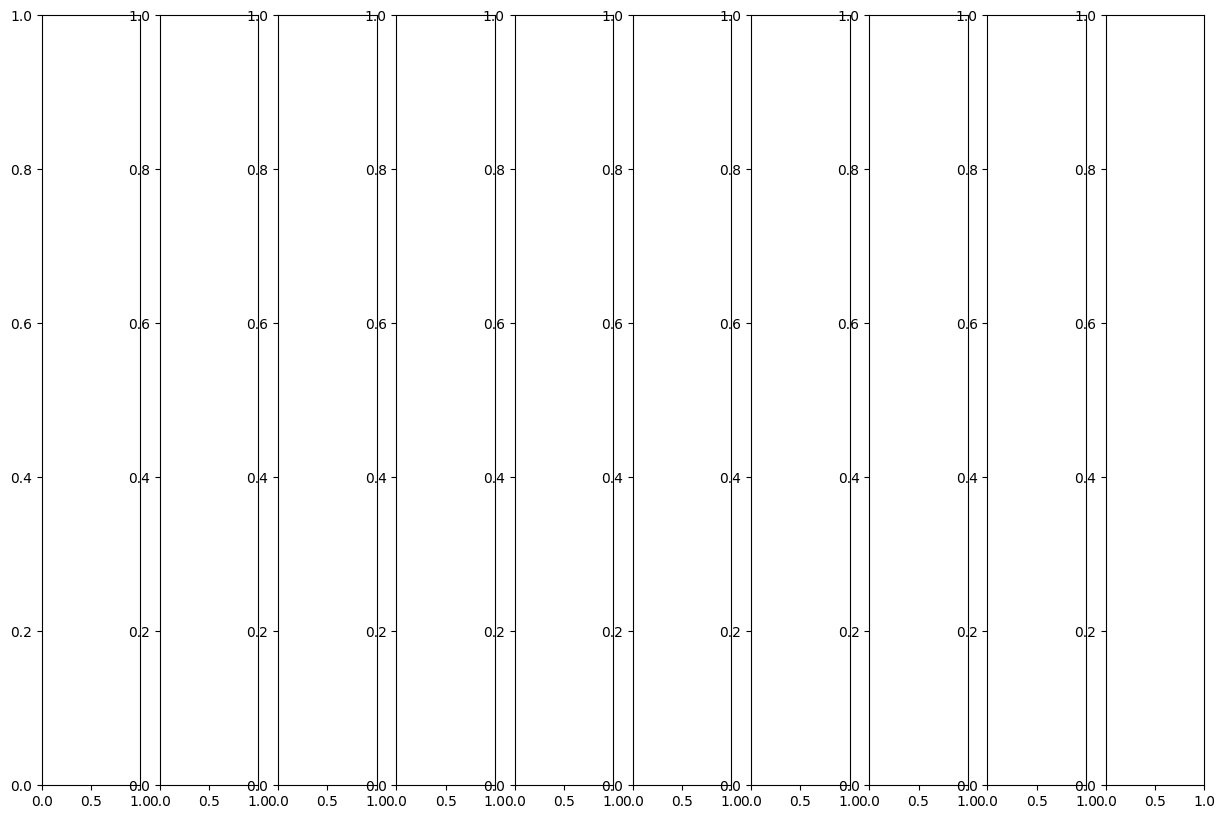

In [13]:
# Plot pixel influence scaled by global SF 
thresholds = [float(i)/100 for i in range(100)]
fig, ax = plt.subplots(1, len(outputs), figsize=(15, 10))
for i, output_node in enumerate(outputs): 
    if [j for j in class_specific_datasets['FP_class'][g]] != []:
        G = (fps[i] - gall).g
        im = []
        for threshold in thresholds: 
            img, fan_in,pixels = visualize_fan_in(G, output_node, threshold,True, False,test)
            im.append(img)
        img  = np.average(im,axis=0)
        ax[i].imshow(img,cmap="inferno")
        ax[i].title.set_text(f"{i}-{np.argmax(np.array(model.diff_logic_model.forward(torch.tensor(img).reshape((1,20,20))).cpu().detach()))}")
plt.show()

# Plot pixel influence scaled by global SF 
thresholds = [float(i)/100 for i in range(100)]
fig, ax = plt.subplots(1, len(outputs), figsize=(15, 10))
for i, output_node in enumerate(outputs): 
    if [j for j in class_specific_datasets['FN_class'][g]] != []:
        G = fns[i].g
        im = []
        for threshold in thresholds: 
            img, fan_in,pixels = visualize_fan_in(G, output_node, threshold,True, False,test)
            im.append(img)
        img  = np.average(im,axis=0)
        ax[i].imshow(img,cmap="inferno")
        ax[i].title.set_text(f"{i}-{np.argmax(np.array(model.diff_logic_model.forward(torch.tensor(img).reshape((1,20,20))).cpu().detach()))}")
plt.show()

# Show a pixel's relative importance to specific classes

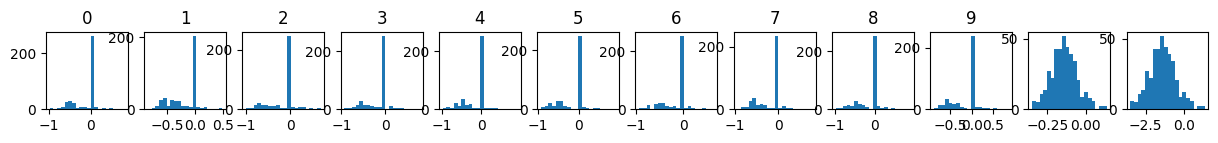

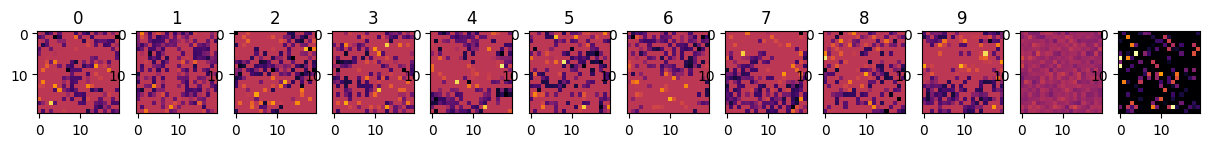

/scratch/local/46700241/ipykernel_235998/4012503970.py:37: RuntimeWarning: invalid value encountered in divide
  ax[i].imshow(np.divide(ims[i],unsigned_average), cmap="inferno",vmin=-4,vmax=4)


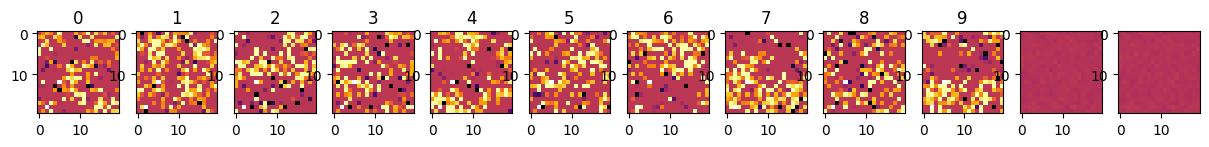

In [18]:
# Plot the unsigned influence
thresholds = [float(i)/100 for i in range(100)]
G = gall.g
ims = [] 
for i, output_node in enumerate(outputs): 
    im = []
    for threshold in thresholds: 
        img, fan_in,pixels = visualize_fan_in(G, output_node, threshold,True, False)
        im.append(img)
    img  = np.average(im,axis=0)
    ims.append(img)

unsigned_average = np.average(ims,axis=0)
unsigned_sum     = np.sum(ims,axis=0)

fig, ax = plt.subplots(1, len(outputs)+2, figsize=(15, 1))
for i, output_node in enumerate(outputs): 
    #ax[i].imshow(np.divide(img[i],unsigned_average), cmap="inferno")
    ax[i].hist(ims[i].flatten().tolist(),bins=20)
    ax[i].title.set_text(f"{i}")
ax[i+1].hist(unsigned_average.flatten().tolist(),bins=20)
ax[i+2].hist(unsigned_sum.flatten().tolist(),bins=20)
plt.show()

fig, ax = plt.subplots(1, len(outputs)+2, figsize=(15, 10))
for i, output_node in enumerate(outputs): 
    #ax[i].imshow(np.divide(img[i],unsigned_average), cmap="inferno")
    ax[i].imshow(ims[i], cmap="inferno",vmin=-1,vmax=1)
    ax[i].title.set_text(f"{i}")
ax[i+1].imshow(unsigned_average, cmap="inferno",vmin=-1,vmax=1)
ax[i+2].imshow(unsigned_sum, cmap="inferno",vmin=-1,vmax=1)
plt.show()

fig, ax = plt.subplots(1, len(outputs)+2, figsize=(15, 10))
for i, output_node in enumerate(outputs): 
    #ax[i].imshow(np.divide(img[i],unsigned_average), cmap="inferno")
    ax[i].imshow(np.divide(ims[i],unsigned_average), cmap="inferno",vmin=-4,vmax=4)
    ax[i].title.set_text(f"{i}")
ax[i+1].imshow(unsigned_average, cmap="inferno",vmin=-4,vmax=4)
ax[i+2].imshow(unsigned_average, cmap="inferno",vmin=-4,vmax=4)
plt.show()

# If you want to see which pixels are important to predicting each class, look at the highlighted pixels for each class

In [ ]:
thresholds = [float(i)/100 for i in range(100)]
#thresholds = [0.0]
outputs = [f"L3_N0", f"L3_N1", f"L3_N2", f"L3_N3", f"L3_N4", f"L3_N5", f"L3_N6", f"L3_N7", f"L3_N8", f"L3_N9"]

# code below currently used for testing, move into a function later
block_gates = ['a', 'and', 'b', 'implied_by', 'implies', 'not_a', 'not_and',
       'not_b', 'not_implied_by', 'not_implies', 'not_or', 'not_xor',
       'one', 'or', 'xor', 'zero']#plot_neural_network(G, positions, model_name_graph)

#block_gates = ['a', 'one', 'zero']#plot_neural_network(G, positions, model_name_graph)
block_gates = []#plot_neural_network(G, positions, model_name_graph)

import copy 
fig, ax = plt.subplots(1, len(outputs)+1, figsize=(15, 10))
for j, output_node in enumerate(outputs): 
    burn = cv2.imread(f"mnist_averages/average_digit_{j}.png")
    ax[j].imshow(burn[4:24,4:24,1])
burn = cv2.imread(f"mnist_averages/average_all_digits.png")
ax[len(outputs)].imshow(burn[4:24,4:24,1])

for i, output_node in enumerate(outputs): 
    #G = gall.g
    G = centered[i].g
    #G = centered[i].g
    im = []
    for threshold in thresholds: 
        img, fan_in,pixels = visualize_fan_in(G, output_node, threshold,False)
        im.append(img)

    fig, ax = plt.subplots(1, len(outputs)+1, figsize=(15, 10))
    img  = np.average(im,axis=0)
    for j, output_node in enumerate(outputs): 
        burn = cv2.imread(f"mnist_averages/average_digit_{j}.png")

        ax[j].imshow(img*burn[4:24,4:24,1],cmap="inferno")
        ax[j].title.set_text(f"{j}")
    ax[len(outputs)].imshow(img,cmap="inferno")
    ax[len(outputs)].title.set_text(f"{i}")

    plt.show()

# If you want to turn an i into a j, remove the highlighted pixels 

In [ ]:
thresholds = [float(i)/100 for i in range(100)]
#thresholds = [0.0]
outputs = [f"L3_N0", f"L3_N1", f"L3_N2", f"L3_N3", f"L3_N4", f"L3_N5", f"L3_N6", f"L3_N7", f"L3_N8", f"L3_N9"]

# code below currently used for testing, move into a function later
block_gates = ['a', 'and', 'b', 'implied_by', 'implies', 'not_a', 'not_and',
       'not_b', 'not_implied_by', 'not_implies', 'not_or', 'not_xor',
       'one', 'or', 'xor', 'zero']#plot_neural_network(G, positions, model_name_graph)

#block_gates = ['a', 'one', 'zero']#plot_neural_network(G, positions, model_name_graph)
block_gates = []#plot_neural_network(G, positions, model_name_graph)

import copy 
fig, ax = plt.subplots(1, len(outputs)+1, figsize=(15, 10))
for j, output_node in enumerate(outputs): 
    burn = cv2.imread(f"mnist_averages/average_digit_{j}.png")
    ax[j].imshow(burn[4:24,4:24,1])
burn = cv2.imread(f"mnist_averages/average_all_digits.png")
ax[len(outputs)].imshow(burn[4:24,4:24,1])

ims = []
for i, output_node in enumerate(outputs): 
    G = centered[i].g
    im = []
    for threshold in thresholds: 
        img, fan_in,pixels = visualize_fan_in(G, output_node, threshold,True, False)
        im.append(img)
    img  = np.average(im,axis=0)
    ims.append(img)
    
fig, ax = plt.subplots(len(outputs), len(outputs), figsize=(15, 15))
for i in range(len(outputs)):
    for j in range(len(outputs)):
        ax[i][j].imshow(ims[i]-ims[j])
        ax[i][j].title.set_text(f"{i}-{j}")

plt.show()

# Product of the matricies to show similar pixels

In [ ]:
thresholds = [float(i)/100 for i in range(100)]
#thresholds = [0.0]
outputs = [f"L3_N0", f"L3_N1", f"L3_N2", f"L3_N3", f"L3_N4", f"L3_N5", f"L3_N6", f"L3_N7", f"L3_N8", f"L3_N9"]

# code below currently used for testing, move into a function later
block_gates = ['a', 'and', 'b', 'implied_by', 'implies', 'not_a', 'not_and',
       'not_b', 'not_implied_by', 'not_implies', 'not_or', 'not_xor',
       'one', 'or', 'xor', 'zero']#plot_neural_network(G, positions, model_name_graph)

#block_gates = ['a', 'one', 'zero']#plot_neural_network(G, positions, model_name_graph)
block_gates = []#plot_neural_network(G, positions, model_name_graph)

import copy 
fig, ax = plt.subplots(1, len(outputs)+1, figsize=(15, 10))
for j, output_node in enumerate(outputs): 
    burn = cv2.imread(f"mnist_averages/average_digit_{j}.png")
    ax[j].imshow(burn[4:24,4:24,1])
burn = cv2.imread(f"mnist_averages/average_all_digits.png")
ax[len(outputs)].imshow(burn[4:24,4:24,1])

ims = []
for i, output_node in enumerate(outputs): 
    G = centered[i].g
    im = []
    for threshold in thresholds: 
        img, fan_in,pixels = visualize_fan_in(G, output_node, threshold,True, False)
        im.append(img)
    img  = np.average(im,axis=0)
    ims.append(img)
    
fig, ax = plt.subplots(len(outputs), len(outputs), figsize=(15, 15))
for i in range(len(outputs)):
    for j in range(len(outputs)):
        ax[i][j].imshow(ims[i]*ims[j])
        ax[i][j].title.set_text(f"{i}*{j}")

plt.show()

# Add/Remove important pixels from each class to see how it changes the class score 

In [ ]:
matches = [] 
for k,(data,label) in enumerate(train_loader.dataset): 
    g = LogicGraph(model.diff_logic_model)
    g.compute_sf(data)
    
    fig, ax   = plt.subplots(1, len(outputs)+1, figsize=(15, 10))
    fig1, ax1 = plt.subplots(1, len(outputs)+1, figsize=(15, 10))
    fig2, ax2 = plt.subplots(1, len(outputs)+1, figsize=(15, 10))
    thresholds = [0.0]
    for i, output_node in enumerate(outputs): 
        im = []
        for threshold in thresholds: 
            img, fan_in,pixels = visualize_fan_in(g.g, output_node, threshold,True,False)
            im.append(img)

        img_f = (img/2+0.5)
        img = np.average(im,axis=0)
        ax[i].imshow(img)
        ax[i].title.set_text(f"{i}-{np.sum(np.abs(img))}-{np.argmax(np.array(g.forward(torch.tensor(img_f).reshape((1,20,20))).cpu().detach()))}")

        im2 = np.array(data[0])
        match = ((img_f == 0) & (im2 == 0) | (img_f == 1) & (im2 == 1))
        matches.append(match)
        ax1[i].imshow(match)
        ax1[i].title.set_text(f"{i}-{np.sum(match)}")

        ax2[i].imshow(np.array(data[0])-img)
        ax2[i].title.set_text(f"{i}-{np.argmax(np.array(g.forward(torch.tensor(np.array(data)-img)).cpu().detach()))}")

        
    ax[len(outputs)].imshow(data.reshape((20,20,1)))
    ax[len(outputs)].title.set_text(f"{np.argmax(np.array(g.forward(data).cpu().detach()))}")

    ax1[len(outputs)].imshow(data.reshape((20,20,1)))
    ax1[len(outputs)].title.set_text(f"{np.argmax(np.array(g.forward(data).cpu().detach()))}")

    ax2[len(outputs)].imshow(data.reshape((20,20,1)))
    ax2[len(outputs)].title.set_text(f"{np.argmax(np.array(g.forward(data).cpu().detach()))}")
    
    plt.show()
    
    if k >= 0: 
        break 


# Show how the class score changes as the image is changed 
### (straight line through the image space)

In [ ]:
pstart = 9
pend   = 2
incs   = 10

imstart = copy.deepcopy(pixel_masks[pstart])
imend   = copy.deepcopy(pixel_masks[pend])

dim = (imend - imstart)/(incs+1)

curr_im = imstart 
fig, ax = plt.subplots(1, incs, figsize=(15, 10))
for i, output_node in enumerate(outputs): 
    curr_im += dim
    pim = curr_im
    ax[i].imshow(np.round(pim))
    ax[i].title.set_text(f"{i}-{np.argmax(np.array(g.forward(torch.tensor(curr_im).reshape((1,20,20))).cpu().detach()))}")


# Compare against other explanation methods 


In [ ]:
0.5/(1/400)

In [ ]:
test = torch.ones((10,10))
torch.linalg.norm(test)

In [83]:
# Integrated Gradients Method
def integrated_gradients(model, input, target_label_idx, baseline=None, steps=50):
    if baseline is None:
        baseline = torch.zeros_like(input).to(input.device)
    
    # Scale inputs and compute gradients
    scaled_inputs = [baseline + (float(i) / steps) * (input - baseline) for i in range(0, steps+1)]
    
    # Store gradients for all inputs
    grads = []
    
    for scaled_input in scaled_inputs:
        #grad = vanilla_gradients(model, scaled_input, target_label_idx)
        #grads.append(grad)
        scaled_input.requires_grad_()
        output = model(scaled_input)
        target = output[0, target_label_idx]
        model.zero_grad()
        target.backward(retain_graph=True)
        grads.append(scaled_input.grad.detach().clone())
    
    # Approximate the integral (Riemann sum)
    avg_grads = torch.mean(torch.stack(grads), dim=0)
    
    # Compute the integrated gradients
    integrated_grad = (input - baseline) * avg_grads
    
    return integrated_grad

# Vanilla Gradients Method
def vanilla_gradients(model, input, target_label_idx):
    input.requires_grad_()
    output = model(input)
    target = output[0, target_label_idx]
    model.zero_grad()
    target.backward()
    return input.grad

def random(model, input, target_label_idx):
    return np.random()

def matrix_to_unit_vector(matrix):
    shape = np.shape(matrix)
    flat_vector = matrix.flatten()
    norm = np.linalg.norm(flat_vector)
    if norm == 0:
        return flat_vector  # Return the zero vector if the norm is zero to avoid division by zero
    return torch.tensor((flat_vector / norm).reshape(shape)).to("cuda")

def sweep_predictions(model,im, grad, steps=10,step_size=1,show=False):

    pred = np.argmax(model(im).cpu().detach().numpy())
    
    # Plot the image and the attributions
    if show: 
        fig, ax = plt.subplots(1, 2*steps+3, figsize=(10, 5))
        ax[steps+1].imshow(   im.cpu().detach().numpy().reshape((20,20,1)), cmap='gray')
        ax[steps+1].title.set_text(f"{pred}")
        ax[steps+1].set_xticks([])  # Remove x-axis ticks
        ax[steps+1].set_yticks([])  # Remove y-axis ticks

        ax[steps+2].imshow( grad.cpu().detach().numpy(), cmap='gray')
        ax[steps+2].title.set_text(f"+grad")
        ax[steps+2].set_xticks([])  # Remove x-axis ticks
        ax[steps+3].set_yticks([])  # Remove y-axis ticks

        ax[steps].imshow(-grad.cpu().detach().numpy(), cmap='gray')
        ax[steps].title.set_text(f"-grad")
        ax[steps].set_xticks([])  # Remove x-axis ticks
        ax[steps].set_yticks([])  # Remove y-axis ticks

    pim = copy.deepcopy(im)
    nim = copy.deepcopy(im)
    
    plabels = [] 
    nlabels = [] 
    
    for i in range(steps): 

        pim = pim+grad*torch.tensor(step_size)
        nim = nim-grad*torch.tensor(step_size) 

        ppred = model(pim)
        npred = model(nim)

        plabel = np.argmax(ppred.cpu().detach().numpy())
        nlabel = np.argmax(npred.cpu().detach().numpy())

        plabels.append(plabel) 
        nlabels.append(nlabel) 
        
        if show: 
            ax[steps+3+i].imshow(pim.cpu().detach().numpy().reshape((20,20,1)), cmap='gray')
            ax[steps+3+i].title.set_text(f"{plabel}")
            ax[steps+3+i].set_xticks([])  # Remove x-axis ticks
            ax[steps+3+i].set_yticks([])  # Remove y-axis ticks
            
            ax[steps-1-i].imshow(nim.cpu().detach().numpy().reshape((20,20,1)), cmap='gray')
            ax[steps-1-i].title.set_text(f"{nlabel}")
            ax[steps-1-i].set_xticks([])  # Remove x-axis ticks
            ax[steps-1-i].set_yticks([])  # Remove y-axis ticks

    plt.show()
    
    return plabels,nlabels


# DiffLogic Saliency Method 
def dl_saliency(model, images, label, dl_type="relevant", precomputed=None, thresholds=None): 

    # Use precomputed when using either class-specific or global explanations
    
    metric = dl_type.split("_")[-1]
    if precomputed != None: 
        g = precomputed
    else: 
        g = LogicGraph(model)
        if metric == "sf": 
            g.compute_sf(images)    
        if metric == "sp": 
            print("!!!IMPLEMENT THE SP METHOD!!!")
            #g.compute_sp(images)    
    
    # Update the operation based on the method 
    if dl_type in ["relevant","local_sf","local_sp"]: 
        thresh=[0.0]
    elif dl_type in ["class_sf","class_sp","global_sf","global_sp"]: 
        thresh=[float(i)/100 for i in range(100)]
    if thresholds: 
        thresh = thresholds
    
    # Get the saliency inputs
    dl = []
    for t in thresh: 
        img, fan_in,pixels = visualize_fan_in(g.g, outputs[label], t,True,False,metric)
        dl.append(img)
    dl = np.average(dl,axis=0)
    #if dl_type in ["local_sf","local_sp"]: 
    #    overlap = np.array(dl==(images*2-1).cpu().detach().numpy()).astype(int)
    #    dl = dl*overlap
    return torch.tensor(dl).reshape(images.shape)

# Function to get calculate saliency maps

# shap_values = e.shap_values(images)
# shap_numpy = list(np.transpose(shap_values, (4, 0, 2, 3, 1)))
# shap_numpy[pred][im]
# print(model.diff_logic_model)

# shap_values = e.shap_values(images)
# shap_numpy = list(np.transpose(shap_values, (4, 0, 2, 3, 1)))
# shap_numpy[pred][im]
# print(model.diff_logic_model)


# Demonstrate several Saliency maps
### Precompute some SF graphs 

In [22]:
# Compute SF for each graph
graphs = {}
for g in range(10): 
    print(f"Class {g}")
    graphs[f"dl_cs_sf_{g}"] = LogicGraph(model.diff_logic_model)
    graphs[f"dl_cs_sf_{g}"].compute_sf(train_class_loaders[g])
    
#graphs["dl_csp"] = LogicGraph(model.diff_logic_model).compute_sf()
graphs["dl_g_sf"] = LogicGraph(model.diff_logic_model)
graphs["dl_g_sf"].compute_sf(train_loader)
#graphs["dl_gsp"] = LogicGraph(model.diff_logic_model).compute_sf()

Class 0


Processing MNIST images: 100%|██████████| 23/23 [00:02<00:00, 10.33it/s]


Class 1


Processing MNIST images: 100%|██████████| 26/26 [00:02<00:00,  9.67it/s]


Class 2


...

Processing MNIST images: 100%|██████████| 24/24 [00:02<00:00, 10.05it/s]


Class 8


Processing MNIST images: 100%|██████████| 22/22 [00:02<00:00, 10.00it/s]


Class 9


Processing MNIST images: 100%|██████████| 234/234 [00:22<00:00, 10.33it/s]


### Demonstrate Vg, IG, and eXpLogic 


In [ ]:
images, labels = next(iter(train_loader))


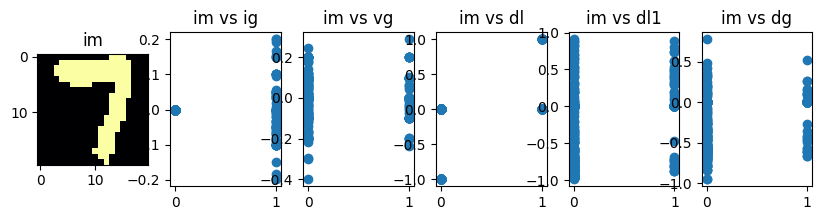

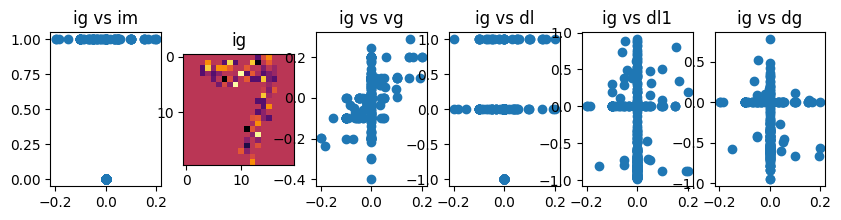

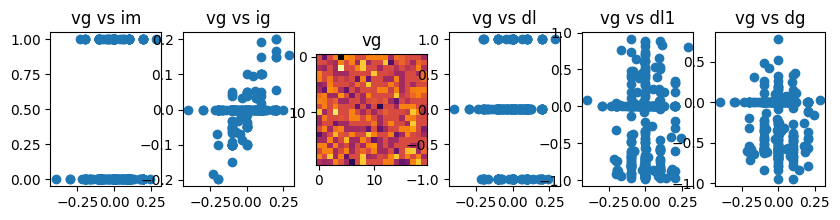

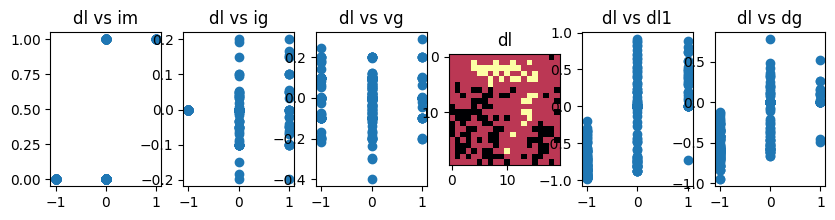

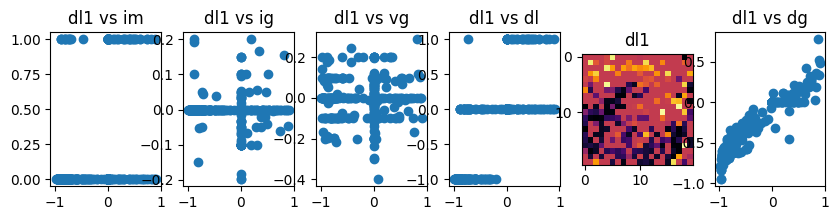

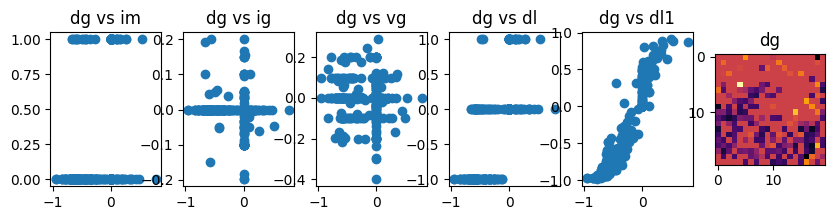

In [59]:
images, labels = next(iter(train_loader))
images = images[0]
labels = labels[0] 
images, labels = images.to("cuda"), labels.to("cuda")

outputs = [f"L3_N0", f"L3_N1", f"L3_N2", f"L3_N3", f"L3_N4", f"L3_N5", f"L3_N6", f"L3_N7", f"L3_N8", f"L3_N9"]

# Pick the target label (the correct class for the test image)
target_label_idx = labels.item()

# Compute the integrated gradients for the image
gall.net.train()
ig = integrated_gradients(gall.net, images, target_label_idx, steps=50)

# Visualize the IG attributions
import matplotlib.pyplot as plt
ig = ig.squeeze().cpu().numpy()

# Compute the diff logic saliency map for the image
dl = dl_saliency(gall.net, images, target_label_idx,dl_type="local_sf")
dl = dl.squeeze().cpu().numpy()

# Compute the diff logic saliency map for the image
dl1 = dl_saliency(gall.net, images, target_label_idx,dl_type="class_sf",precomputed=graphs[f"dl_cs_sf_{target_label_idx}"])
dl1 = dl1.squeeze().cpu().numpy()

# Compute the diff logic saliency map for the image
dl2 = dl_saliency(gall.net, images, target_label_idx,dl_type="global_sf",precomputed=graphs[f"dl_g_sf"])
dl2 = dl2.squeeze().cpu().numpy()

# Compute the vanilla gradients for the image
gall.net.train()
vg = vanilla_gradients(gall.net, images, target_label_idx)
vg = vg.squeeze().cpu().numpy()

# Plot the image and the attributions
im   = images.squeeze().cpu().detach().numpy()
data = {"im":im, "ig":ig, "vg":vg, "dl":dl, "dl1":dl1, "dg":dl2}
for i, k1 in enumerate(data.keys()): 
    d1 = data[k1]
    fig, ax = plt.subplots(1, len(data), figsize=(10, 2))
    for j, k2 in enumerate(data.keys()): 
        d2 = data[k2]
        if i == j: 
            ax[j].imshow(d1, cmap='inferno')
            ax[j].set_title(k1)
        else: 
            ax[j].scatter(d1.flatten(), d2.flatten())
            ax[j].set_title(f"{k1} vs {k2}")
            

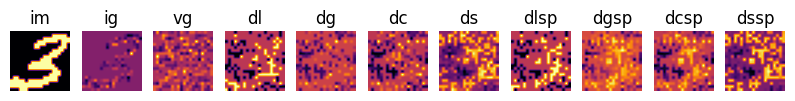

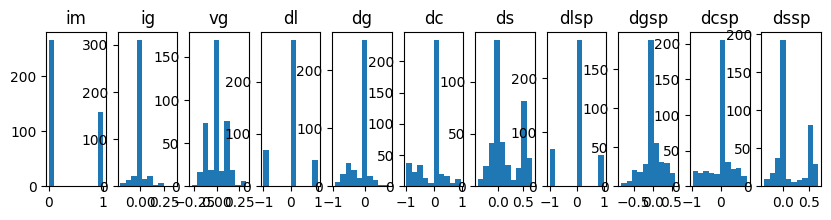

In [86]:
images, labels = next(iter(train_loader))
images = images[0]
labels = labels[0] 
images, labels = images.to("cuda"), labels.to("cuda")

outputs = [f"L3_N0", f"L3_N1", f"L3_N2", f"L3_N3", f"L3_N4", f"L3_N5", f"L3_N6", f"L3_N7", f"L3_N8", f"L3_N9"]

# Pick the target label (the correct class for the test image)
target_label_idx = labels.item()

# Compute the integrated gradients for the image
gall.net.train()
ig = integrated_gradients(gall.net, images+0.001, target_label_idx, steps=50)

# Visualize the IG attributions
import matplotlib.pyplot as plt
ig = ig.squeeze().cpu().numpy()

# Compute the diff logic saliency map for the image
dl = dl_saliency(gall.net, images, target_label_idx,dl_type="local_sf")
dl = dl.squeeze().cpu().numpy()

# Compute the diff logic saliency map for the image
gall.compute_sp(images)
dlsp = dl_saliency(gall.net, images, target_label_idx,dl_type="local_sp",precomputed=gall)
dlsp = dlsp.squeeze().cpu().numpy()

# Compute the diff logic saliency map for the image
dl1 = dl_saliency(gall.net, images, target_label_idx,dl_type="class_sf",precomputed=graphs[f"dl_cs_sf_{target_label_idx}"])
dl1 = dl1.squeeze().cpu().numpy()

# Compute the diff logic saliency map for the image
dl1sp = dl_saliency(gall.net, images, target_label_idx,dl_type="class_sp",precomputed=sp_graphs[target_label_idx])
dl1sp = dl1sp.squeeze().cpu().numpy()

# Compute the diff logic saliency map for the image
dls = dl_saliency(gall.net, images, target_label_idx,dl_type="global_sf",precomputed=specific[target_label_idx],thresholds=[float(i)/50-1 for i in range(100)])
dls = dls.squeeze().cpu().numpy()

# Compute the diff logic saliency map for the image
dlssp = dl_saliency(gall.net, images, target_label_idx,dl_type="global_sp",precomputed=sp_diffs[target_label_idx],thresholds=[float(i)/50-1 for i in range(100)])
dlssp = dlssp.squeeze().cpu().numpy()

# Compute the diff logic saliency map for the image
dl2 = dl_saliency(gall.net, images, target_label_idx,dl_type="global_sf",precomputed=graphs[f"dl_g_sf"])
dl2 = dl2.squeeze().cpu().numpy()

# Compute the diff logic saliency map for the image
avg = cv2.imread(f"mnist_averages/average_all_digits.png")[4:24,4:24,1]/255
gall.compute_sp(avg)
dl2sp = dl_saliency(gall.net, images, target_label_idx, dl_type="global_sp",precomputed=gall)
dl2sp = dl2sp.squeeze().cpu().numpy()

# Compute the vanilla gradients for the image
gall.net.train()
vg = vanilla_gradients(gall.net, images, target_label_idx)
vg = vg.squeeze().cpu().numpy()

# Plot the image and the attributions
im   = images.squeeze().cpu().detach().numpy()
data = {"im":im, "ig":ig, "vg":vg, "dl":dl, "dg":dl2, "dc":dl1, "ds":dls, "dlsp":dlsp, "dgsp":dl2sp, "dcsp":dl1sp, "dssp":dlssp}
fig, ax = plt.subplots(1, len(data), figsize=(10, 2))
for j, k2 in enumerate(data.keys()): 
    d1 = data[k2]
    ax[j].imshow(d1, cmap='inferno')
    ax[j].set_title(k2)
    ax[j].set_axis_off()
    
# Plot the image and the attributions
im   = images.squeeze().cpu().detach().numpy()
data = {"im":im, "ig":ig, "vg":vg, "dl":dl, "dg":dl2, "dc":dl1, "ds":dls, "dlsp":dlsp, "dgsp":dl2sp, "dcsp":dl1sp, "dssp":dlssp}
fig, ax = plt.subplots(1, len(data), figsize=(10, 2))
for j, k2 in enumerate(data.keys()): 
    d1 = data[k2]
    ax[j].hist(np.array(d1.flatten()))
    ax[j].set_title(k2)
    #ax[j].set_axis_off()


(array([  28.,  223.,  453.,  740., 1007., 1402.,  786.,  455.,  268.,
          50.]),
 array([-0.47636327, -0.38253782, -0.28871237, -0.19488693, -0.10106148,
        -0.00723603,  0.08658941,  0.18041486,  0.27424031,  0.36806575,
         0.4618912 ]),
 <BarContainer object of 10 artists>)

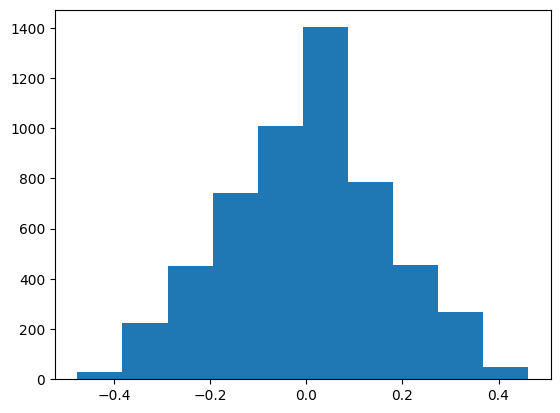

In [80]:
data = nx.get_node_attributes(specific[target_label_idx].g,"sf")
data = [data[d] for d in data.keys()]
plt.hist(data)

data = nx.get_node_attributes(specific[target_label_idx].g,"sf")
data = [data[d] for d in data.keys()]
plt.hist(data)

In [ ]:
norm = torch.linalg.matrix_norm(s) 
test = s/norm
sum(sum(test))

In [ ]:
def torch_norm(torch_matrix): 
    # Convert the saliency map into a unit vector (direction) 
    unit_matrix = torch_matrix.view(-1)
    norm        = torch.linalg.matrix_norm(torch_matrix) 
    unit_vector = unit_matrix / norm
    unit_matrix = unit_vector.view(torch_matrix.shape)
    return unit_matrix 
    

In [ ]:
ani

In [ ]:
saliency = torch.Tensor(dls)

# Convert the saliency map into a unit vector (direction) 
unit_matrix = saliency.view(-1)
norm        = torch.norm(unit_matrix, p=2)
unit_vector = unit_matrix / norm
unit_matrix = unit_vector.view(saliency.shape)

u = unit_matrix.cpu().detach().numpy()
nimp   = np.array(np.abs(u - np.mean(u))<np.std(u - np.mean(u))).astype(int)


In [ ]:
# Plot the image and the attributions
s    = saliency.squeeze().cpu().detach().numpy()
nimp = nimp

data = {"im":im,"s":s, "nimp":nimp,"im*s":nimp*s}
fig, ax = plt.subplots(1, len(data), figsize=(10, 2))
for j, k2 in enumerate(data.keys()): 
    d1 = data[k2]
    ax[j].imshow(d1)
    ax[j].set_title(k2)
    #ax[j].set_axis_off()

# Visualize the primary target image methods
---------
Remove important pixels
---------
- Add/Remove what's important (The class should be quick to change) 
- Remove what's important and positive (The class should be quick to change) 
- Add what's important and negative (The class should be quick to change) 
---------
Add unimportant pixels
---------
- Add/Remove what's not important (The class should be slow to change)
- Remove what's not important and positive (The class should be slow to change)
- Add what's not important and negative (The class should be slow to change)
---------

In [ ]:
im.shape

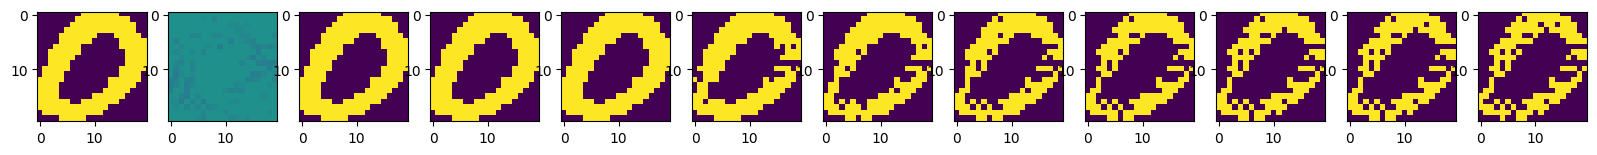

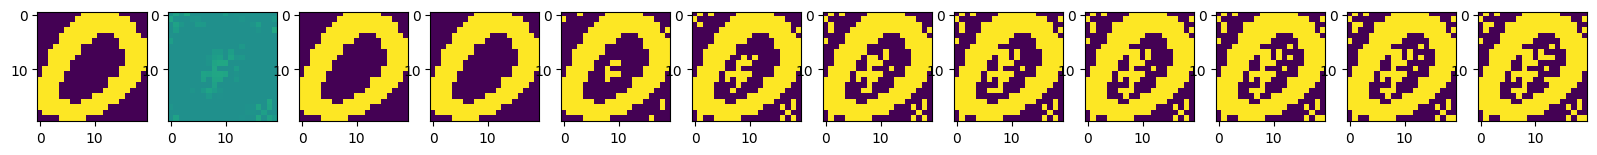

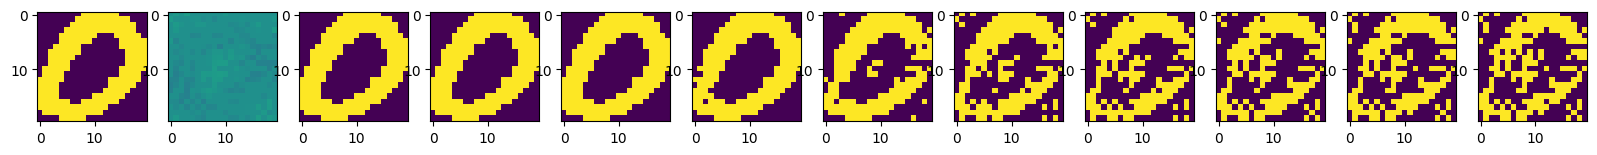

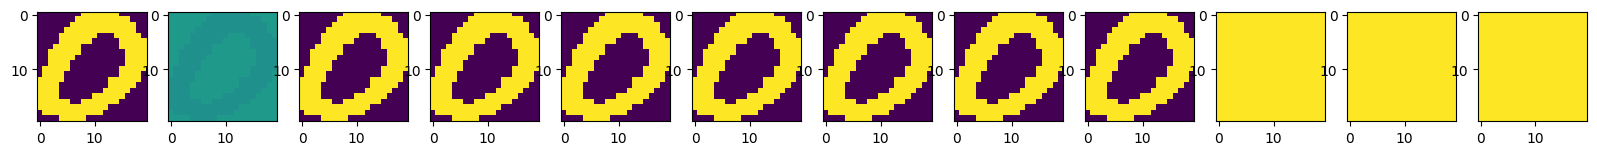

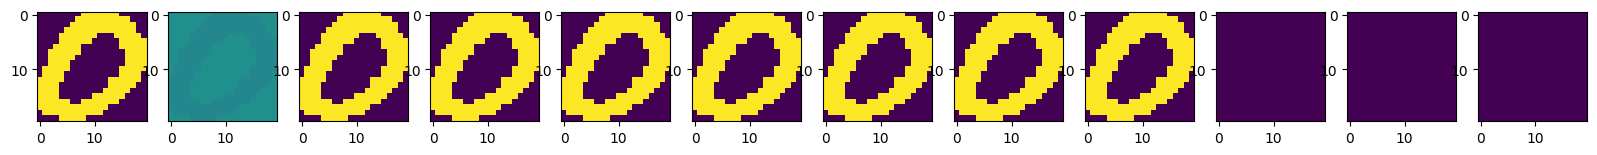

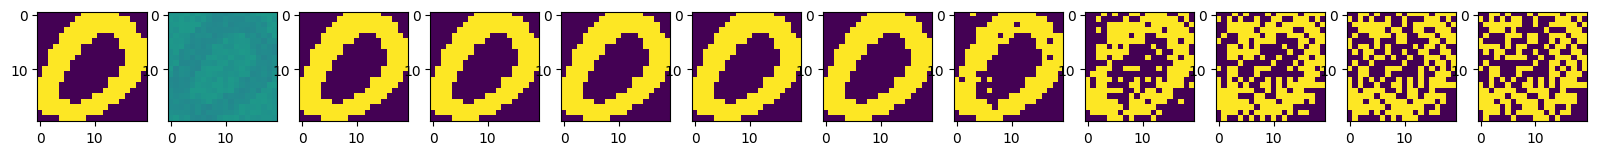

In [45]:
def plot_n(im, saliency, n,step=0.1,vmin=0,vmax=1): 
    fig, ax = plt.subplots(1, n+2, figsize=(20, 2))
    ax[0].imshow(im,vmin=vmin,vmax=vmax)
    ax[1].imshow(saliency,vmin=-1,vmax=+1)
    plt_im = copy.deepcopy(im)
    for i in range(n):
        plt_im = plt_im + saliency*step
        ax[2+i].imshow(plt_im>0.5,vmin=vmin,vmax=vmax)
    plt.show()


# Select the saliency map 
saliency = dls
step     = 1
nims     = 10
dirs     = get_unit_dirs(torch.tensor(im), torch.tensor(saliency),n_rands=1)

for key in dirs.keys(): 
    plot_n(im,dirs[key].cpu().detach().numpy().reshape((20,20)),nims,step)
    

In [40]:
dirs.keys()

dict_keys(['rip', 'rin', 'ri', '1', '0', 'r0'])

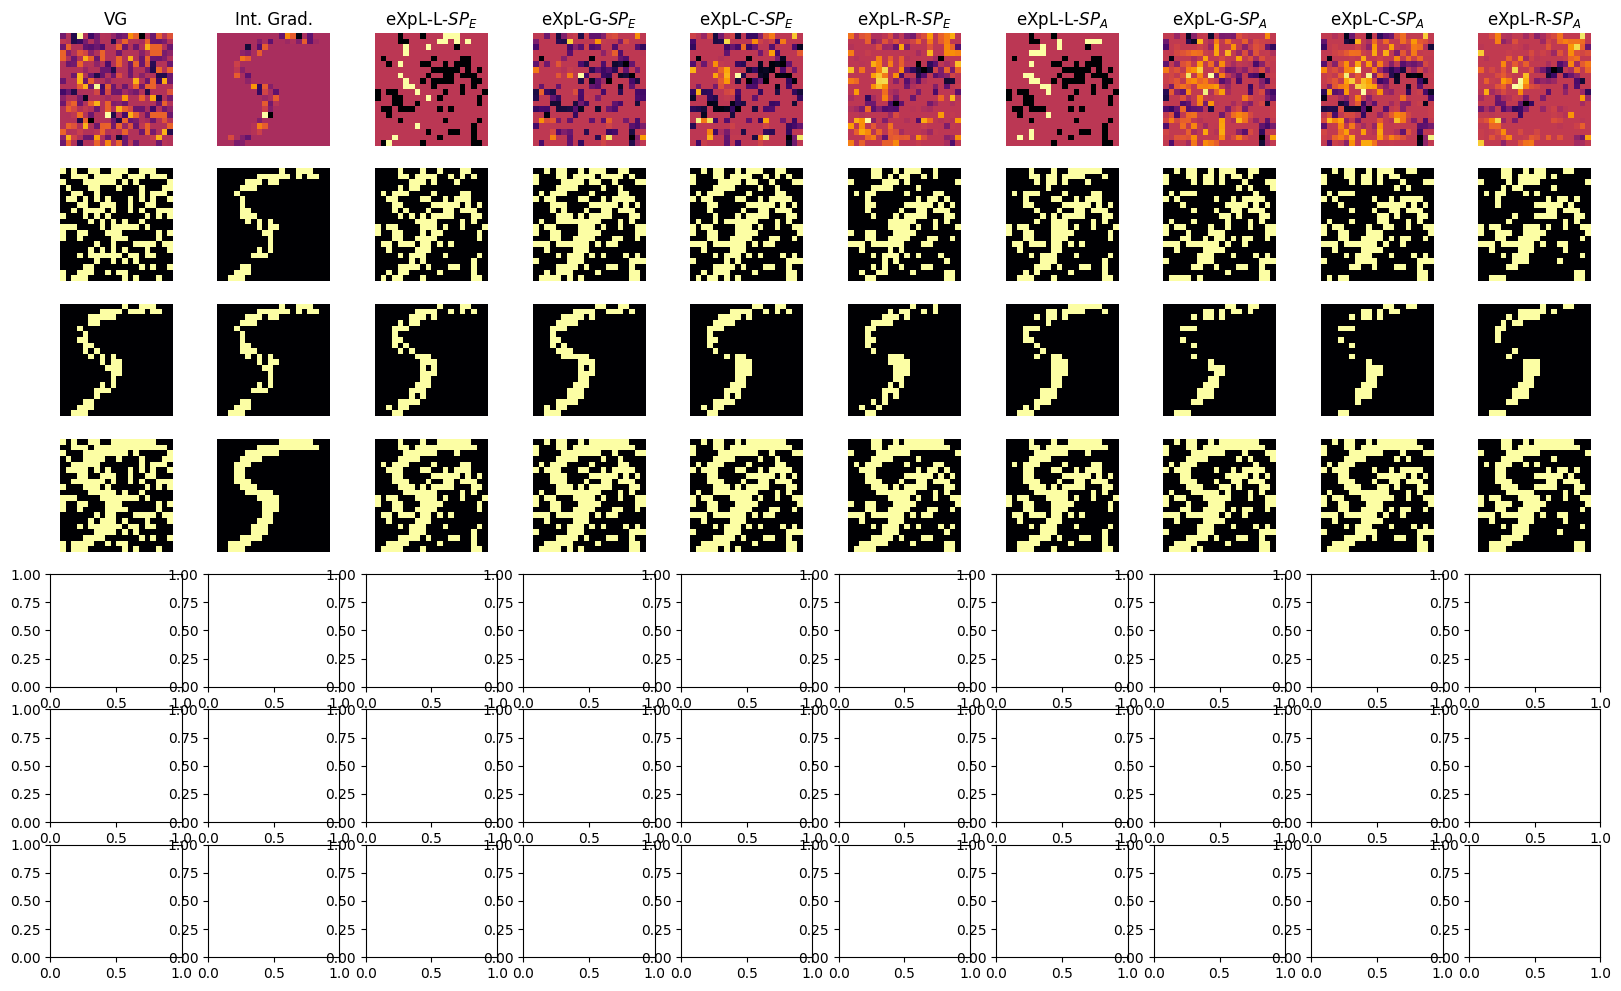

In [63]:
def get_last(im, saliency, n,step=0.1,vmin=0,vmax=1): 
    plt_im = copy.deepcopy(im)
    for i in range(n):
        plt_im = plt_im + saliency*step
    return plt_im

# Select the saliency map 
data = {"VG":vg, "Int. Grad.":ig, "eXpL-L-$SP_E$":dl, "eXpL-G-$SP_E$":dl2, "eXpL-C-$SP_E$":dl1, "eXpL-R-$SP_E$":dls, "eXpL-L-$SP_A$":dlsp, "eXpL-G-$SP_A$":dl2sp, "eXpL-C-$SP_A$":dl1sp, "eXpL-R-$SP_A$":dlssp}
step     = 10
nims     = 10
fig, ax = plt.subplots(7, len(data), figsize=(20, 12))
for i,key in enumerate(data.keys()): 
    saliency = data[key]
    dirs = get_unit_dirs(torch.tensor(im),torch.tensor(saliency))
    
    ax[0,i].imshow(saliency,cmap="inferno") 
    ax[0,i].set_axis_off()

    ax[1,i].imshow(get_last(im, dirs["ri"].cpu().detach().numpy().reshape((20,20)), nims, step=step)>=0.5,vmin=0,vmax=1,cmap="inferno") # Remove the important pixels that are positive
    ax[1,i].set_axis_off()
    
    ax[2,i].imshow(get_last(im, dirs["rip"].cpu().detach().numpy().reshape((20,20)), nims, step=step)>=0.5,vmin=0,vmax=1,cmap="inferno") # Add the important pixels that are negative  
    ax[2,i].set_axis_off()

    ax[3,i].imshow(get_last(im, dirs["rin"].cpu().detach().numpy().reshape((20,20)), nims, step=step)>=0.5,vmin=0,vmax=1,cmap="inferno")          # Remove the important pixels 
    ax[3,i].set_axis_off()
    
    #ax[4,i].imshow(get_last(im, dirs["ani"].cpu().detach().numpy().reshape((20,20)), nims, step=step)>=0.5,vmin=0,vmax=1,cmap="inferno") # Remove the important pixels that are positive
    #ax[4,i].set_axis_off()
    
    #ax[5,i].imshow(get_last(im, dirs["anip"].cpu().detach().numpy().reshape((20,20)), nims, step=step)>=0.5,vmin=0,vmax=1,cmap="inferno") # Add the important pixels that are negative  
    #ax[5,i].set_axis_off()

    #ax[6,i].imshow(get_last(im, dirs["anin"].cpu().detach().numpy().reshape((20,20)), nims, step=step)>=0.5,vmin=0,vmax=1,cmap="inferno")          # Remove the important pixels 
    #ax[6,i].set_axis_off()

    ax[0,i].set_title(f"{key}")
    ax[0,0].set_ylabel(f"Method")
    ax[1,0].set_ylabel("+ Imp.")
    ax[2,0].set_ylabel(f"- Imp.")
    ax[3,0].set_ylabel(f"+/- Imp.")
    #ax[4,0].set_ylabel(f"+(!) Imp.")
    #ax[5,0].set_ylabel(f"-(!) Imp.")
    #ax[6,0].set_ylabel(f"+/-(!) Imp.")
    

In [ ]:
dtype = "sin"
test = get_dists(model.diff_logic_model, dl_saliency, "dl_c_sf", image, label, step_size, n_rands, precomputed=graphs[f"dl_c_sf_{label}"], dl_type="class_sf")
test[f"dl_c_sf_d_{dtype}"]

# Study the distance needed to change the class score in the "direction of input saliency"

In [37]:

def torch_norm(torch_matrix): 
    # Convert the saliency map into a unit vector (direction) 
    unit_matrix = torch_matrix.view(-1)
    norm        = torch.linalg.matrix_norm(torch_matrix) 
    unit_vector = unit_matrix / norm
    unit_matrix = unit_vector.view(torch_matrix.shape)
    return unit_matrix 
    
# Helper function to compute the target (end) points when searching for a class change  
def get_unit_dirs(image, saliency, n_rands=10,plot=False): 
    
    im   = image.to("cuda")
    s    = saliency.to("cuda")
    u    = torch_norm(s)
    std  = torch.std(u - torch.mean(u))
    nimp = (torch.abs(u - torch.mean(u))<=std).to(int)
    imp  = (torch.abs(u - torch.mean(u))>std).to(int)

    tol = std/1000

    # Get primitives 
    pos  = (u + tol >  0).to(int)
    neg  = (u - tol <= 0).to(int) 

    # Initialize all targets
    targets = {} 
    targets["rip"]  = torch_norm(-u*pos)
    targets["rin"]  = torch_norm(-u*neg)
    targets["ri"]   = -u
    #targets["anip"] = torch_norm((u+tol)*nimp*pos*(im==0))
    #targets["anin"] = torch_norm((u-tol)*nimp*neg*(im==1))
    #targets["ani"]  = torch_norm(targets["anip"]*(im==0) + targets["anin"]*(im==1))   

    # Get the baseline targets 
    targets["1"]    = torch_norm(torch.ones(np.shape(saliency)).to("cuda") - im)
    targets["0"]    = torch_norm(torch.zeros(np.shape(saliency)).to("cuda") - im)
    for i in range(n_rands): 
        targets[f"r{i}"] = torch_norm(torch.rand(np.shape(saliency)).to("cuda") - im)
    
    if plot: 
        #data = {"im":im.reshape((20,20,1)),"s":s,"u":u,"imp":1-nimp,"nimp":nimp,"pos":pos,"neg":neg,"ri":ri.reshape((20,20,1)),"rip":rip.reshape((20,20,1)),"rin":rin.reshape((20,20,1)),"ani":ani.reshape((20,20,1)),"anip":anip.reshape((20,20,1)),"anin":anin.reshape((20,20,1)),"sum":(ri + ani).reshape((20,20,1)),"zeros":((ri + ani)==0).reshape((20,20,1))}
        fig, ax   = plt.subplots(1, len(targets.keys())+5, figsize=(30, 2))
        fig1, ax1 = plt.subplots(1, len(targets.keys())+5, figsize=(30, 2))
        ax[0].imshow(im.cpu().detach().numpy().reshape((20,20,1)),vmin=-0.25,vmax=0.25,cmap="inferno")
        ax[0].set_title("im")
        ax[0].set_axis_off()
        ax[1].imshow(s.cpu().detach().numpy().reshape((20,20,1)),vmin=-0.25,vmax=0.25,cmap="inferno")
        ax[1].set_title("s")
        ax[1].set_axis_off()
        for j, k2 in enumerate(targets.keys()): 
            d1 = targets[k2].cpu().detach().numpy()
            ax[j+2].imshow(d1.reshape((20,20,1)),vmin=-0.25,vmax=0.25,cmap="inferno")
            ax[j+2].set_title(k2)
            ax1[j+2].hist(d1.flatten())
            ax1[j+2].set_title(np.round(np.linalg.norm(d1),2))
            ax[j+2].set_axis_off()
        ax[j+3].imshow(imp.cpu().detach().numpy().reshape((20,20,1)),vmin=-0.25,vmax=0.25,cmap="inferno")
        ax[j+3].set_title("!imp")
        ax[j+3].set_axis_off()
        ax[j+4].imshow(nimp.cpu().detach().numpy().reshape((20,20,1)),vmin=-0.25,vmax=0.25,cmap="inferno")
        ax[j+4].set_title("!imp")
        ax[j+4].set_axis_off()
    
    return targets



# Function to find the distance between two methods 
# TODO: Change this to a search algorithm that finds the decision boundary within some tolerance 
# TODO: Add the option to move away from not-class targets
def find_dists(model, image, label, unit_dir, step_size, stop_at_min = True): 
    
    # Predict the class score each time the image is changed
    dmin   = None
    dist   = 0 
    labels = [] 
    im_copy = copy.deepcopy(image).to("cuda")
    iterations = 0 
    while dist < 100: 

        # Predict the class score 
        c = np.argmax(model((im_copy>0.5).to(int).to(float)).cpu().detach().numpy())
        labels.append(c)
        
        # Update the image 
        im_copy  = im_copy + unit_dir*step_size
        if dmin == None and label != c:

            # Calculate the hamming distance 
            dmin = dist
            
            if stop_at_min: 
                break 
        
        # Update the current distance 
        dist       += step_size 
        iterations += 1

    if dmin == None: 
        dmin = dist
        
    del image
    del unit_dir
    return dmin, labels, iterations

# Function to get calculate distance from image that changes the class score 
def get_dists(model, function, abreviation, image, label, step_size, n_rands, **kwargs): 
    
    # Get the Integrated Gradients saliency maps
    start_time = time.time()
    saliency = function(model, image, label, **kwargs)
    end_time = time.time()
    elapsed_time = end_time - start_time

    #saliency = saliency.squeeze().cpu().numpy()
    # Predict the class score 
    unit_dirs  = get_unit_dirs(image,saliency, n_rands)

    # Find the distance needed to change the class prediction 
    dists = {f"{abreviation}_s": saliency.flatten().cpu().detach().numpy(), f"{abreviation}_t":elapsed_time} 
    for key in unit_dirs.keys(): 
        unit_dir                        = unit_dirs[key]
        min_dist, classes,iterations    = find_dists(model, image, label, unit_dir, step_size)
        dists[f"{abreviation}_d_{key}"] = min_dist 
        dists[f"{abreviation}_c_{key}"] = classes 
        #dists[f"{abreviation}_i_{key}"] = iterations 
        
    return dists

In [ ]:
im   = images.to("cuda")
print("vg")
dirs = get_unit_dirs(im,torch.Tensor(vg),n_rands=1,plot=True)
print("Integrated Gradients")
dirs = get_unit_dirs(im,torch.Tensor(ig),n_rands=1,plot=True)
print("Local")
dirs = get_unit_dirs(im,torch.Tensor(dl),n_rands=1,plot=True)
print("Specific")
dirs = get_unit_dirs(im,torch.Tensor(dls),n_rands=1,plot=True)


In [27]:
p_maps = []
sp_graphs = [] 
sp_diffs = [] 
for j, output_node in enumerate(outputs): 
    p_maps.append(cv2.imread(f"mnist_averages/average_digit_{j}.png")[4:24,4:24,1]/255)
    sp_graph  = copy.deepcopy(gall)
    sp_graph.compute_sp(p_maps[j])
    sp_graphs.append(sp_graph)
    sp_diffs.append(sp_graph.sub_sp(gall))

In [ ]:
# Set parameters for the dataset creation 
num_gen    = 4
step_size  = 0.1
save_every = 10 
ig_steps   = 20
test_explanations = False
n_rands    = 5
thresholds = [float(i)/100 for i in range(100)]
import time 
dicts = [] 
test = False 
# Produce the explanations per image in the MNIST dataset
for j,(images, labels) in enumerate(iter(train_loader)): 
    for i, (image, label) in enumerate(zip(images,labels)): 

        # Condition the negative images
        print("image")  if test else None
        image, label = image.to("cuda"), label.to("cuda")

        # Initialize the data structure
        print("dists")  if test else None
        dists = {"label": label.item(), "image":image.flatten().cpu().detach().numpy()}
        model.diff_logic_model.train()

        # Get the integrated gradients explanations 
        print("integrated_gradients") if test else None
        dists = dists | get_dists(model.diff_logic_model, integrated_gradients, "ig", image, label, step_size, n_rands, steps=ig_steps) 

        # Get the vanilia gradients explanations 
        print("vanilla_gradients") if test else None
        dists = dists | get_dists(model.diff_logic_model, vanilla_gradients, "vg", image, label, step_size, n_rands) 
        
        print("dl_saliency_sp") if test else None
        gall.compute_sp(p_maps[label.item()])
        dists = dists | get_dists(model.diff_logic_model, dl_saliency, "dl_l_sp", image, label, step_size, n_rands, precomputed=gall, dl_type="local_sp") 

        # Get the vanilia gradients explanations 
        #dists = dists | get_dists(model.diff_logic_model, vanilla_gradients, "lime", image, label, step_size, n_rands) 

        # Get the vanilia gradients explanations 
        #dists = dists | get_dists(model.diff_logic_model, vanilla_gradients, "shap", image, label, step_size, n_rands)         
        
        # Get the difflogic explanations (class-specific)
        # dists = dists | get_dists(model.diff_logic_model, dl_saliency, "dl", image, label, step_size, n_rands, dl_type="relevant") 

        # Get the difflogic explanations 
        print("dl_saliency") if test else None
        dists = dists | get_dists(model.diff_logic_model, dl_saliency, "dl_l_sf", image, label, step_size, n_rands, dl_type="local_sf") 
        print("dl_saliency") if test else None
        gall.compute_sp(image)
        dists = dists | get_dists(model.diff_logic_model, dl_saliency, "dl_l_sp", image, label, step_size, n_rands, precomputed=gall, dl_type="local_sp") 

        # Get the difflogic explanations 
        #dists = dists |  get_dists(model.diff_logic_model, dl_saliency, "dl_l_sp", image, label, step_size, n_rands, dl_type="local_sp") 

        # Get the difflogic explanations 
        print("dl_c_sf") if test else None
        dists = dists | get_dists(model.diff_logic_model, dl_saliency, "dl_c_sf", image, label, step_size, n_rands, precomputed=graphs[f"dl_cs_sf_{label}"], dl_type="class_sf") 
        print("dl_c_sp") if test else None
        dists = dists | get_dists(model.diff_logic_model, dl_saliency, "dl_c_sp", image, label, step_size, n_rands, precomputed=sp_graphs[label.item()], dl_type="class_sp") 

        # Get the difflogic explanations 
        print("dl_s_sf") if test else None
        dists = dists | get_dists(model.diff_logic_model, dl_saliency, "dl_s_sf", image, label, step_size, n_rands, precomputed=specific[label.item()], dl_type="class_sf",thresholds=[float(i)/50-1 for i in range(100)]) 
        print("dl_s_sp") if test else None
        dists = dists | get_dists(model.diff_logic_model, dl_saliency, "dl_s_sp", image, label, step_size, n_rands, precomputed=sp_diffs[label.item()], dl_type="class_sp",thresholds=[float(i)/50-1 for i in range(100)]) 
        
        # Get the difflogic explanations 
        #dists = dists | get_dists(model.diff_logic_model, dl_saliency, "dl_c_sp", image, label, step_size, n_rands, precomputed=graphs[f"dl_c_sp_{label}"], dl_type="class_sp") 

        # Get the difflogic explanations 
        print("dl_g_sf") if test else None
        dists = dists | get_dists(model.diff_logic_model, dl_saliency, "dl_g_sf", image, label, step_size, n_rands, precomputed=graphs["dl_g_sf"], dl_type="global_sf") 
        print("dl_g_sp") if test else None
        gall.compute_sp(np.ones((20,20))-0.5)
        dists = dists | get_dists(model.diff_logic_model, dl_saliency, "dl_g_sp", image, label, step_size, n_rands, precomputed=gall, dl_type="global_sp") 
        print("dl_z_sp") if test else None
        gall.compute_sp(avg)
        dists = dists | get_dists(model.diff_logic_model, dl_saliency, "dl_z_sp", image, label, step_size, n_rands, precomputed=gall, dl_type="global_sp") 
        
        # Get the difflogic explanations 
        #dists = dists | get_dists(model.diff_logic_model, dl_saliency, "dl_g_sp", image, label, step_size, n_rands, precomputed=graphs["dl_g_sp"], dl_type="global_sp") 

        # Save the dictionaries
        dicts.append(dists)
        if i%save_every==0: 
            
            # Save list of dictionaries to CSV
            import csv 
            with open(f'./outputs/output_{j}_{i}.csv', 'w', newline='') as csvfile:
                print("saved: ", f'output_{i}.csv')
                # Get the headers from the keys of the first dictionary
                fieldnames = dicts[0].keys()

                writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

                # Write the header row
                writer.writeheader()

                # Write the data rows
                writer.writerows(dicts)            
            
            dicts = [] 
            
        # Stop short
        if test_explanations: 
            break
    
    # Stop short
    if test_explanations: 
        break


saved:  output_0.csv
saved:  output_10.csv
saved:  output_20.csv
saved:  output_30.csv
saved:  output_40.csv
saved:  output_50.csv
saved:  output_60.csv
saved:  output_70.csv
saved:  output_80.csv
saved:  output_90.csv
saved:  output_100.csv
saved:  output_110.csv
saved:  output_120.csv
saved:  output_130.csv
saved:  output_140.csv
saved:  output_150.csv
saved:  output_160.csv
saved:  output_170.csv
saved:  output_180.csv
saved:  output_190.csv
saved:  output_200.csv
saved:  output_210.csv
saved:  output_220.csv
saved:  output_230.csv
saved:  output_240.csv
saved:  output_250.csv
saved:  output_0.csv
saved:  output_10.csv
saved:  output_20.csv
saved:  output_30.csv
saved:  output_40.csv
saved:  output_50.csv
saved:  output_60.csv
saved:  output_70.csv
saved:  output_80.csv
saved:  output_90.csv
saved:  output_100.csv
saved:  output_110.csv
saved:  output_120.csv
saved:  output_130.csv
saved:  output_140.csv
saved:  output_150.csv
saved:  output_160.csv
saved:  output_170.csv
saved:  ou

In [ ]:
sp_graphs[0]

# Test the SHAP method 

In [ ]:
import shap

In [ ]:
batch = next(iter(test_loader))
batch = next(iter(test_loader))
images, _ = batch

background = images[:256].to("cuda").requires_grad_()
test_images = images[68:103].to("cuda").requires_grad_()

e = shap.GradientExplainer(model.diff_logic_model.train(), background)
model.diff_logic_model.train()
shap_values = e.shap_values(test_images)

shap_numpy = list(np.transpose(shap_values, (4, 0, 2, 3, 1)))
test_numpy = np.swapaxes(np.swapaxes(test_images.cpu().detach().numpy(), 1, -1), 1, 2)
shap.image_plot(shap_numpy, -test_numpy)


In [ ]:
plt.imshow(image.cpu().detach().numpy().reshape((20,20,1)))

In [ ]:
p_masks[j]

In [ ]:
# Plot pixel attribution  
thresholds = [0.0]
p_masks = [] 
for i, output_node in enumerate(outputs): 
    G = centered[i].g
    im = []
    for threshold in thresholds: 
        img, fan_in,pixels = visualize_fan_in(G, output_node, threshold,False, False)
        im.append(img)
    img  = np.average(im,axis=0)
    p_masks.append(img)

# Plot positive and negative pixel attribution 
thresholds = [0.0]
pn_masks = [] 
for i, output_node in enumerate(outputs): 
    G = centered[i].g
    im = []
    for threshold in thresholds: 
        img, fan_in,pixels = visualize_fan_in(G, output_node, threshold,True, False)
        im.append(img)
    img  = np.average(im,axis=0)
    pn_masks.append(img)


## Plot positive and negative pixel attribution 
thresholds = [0.0]
figt, axt  = plt.subplots(1, len(outputs)+1, figsize=(15, 15))
fig,   ax  = plt.subplots(len(outputs), len(outputs)+1, figsize=(15, 15))
axt[0].imshow(np.zeros(p_masks[i].shape))
control_pixels = [] 
for i, output_node in enumerate(outputs): 
    axt[i+1].imshow(p_masks[i])
    axt[i+1].title.set_text(f"{i}")
    control_pixels.append([])
    for j, output_node in enumerate(outputs): 
        unique_pos = np.array(((p_masks[i]>0.2) == 1) & ((p_masks[i]>0.2) != (p_masks[j]>0.2))).astype("int")
        if j == 0: 
            ax[i][j].imshow(p_masks[i])
            ax[i][j].title.set_text(f"{j}")
        
        control_pixels[i].append(pn_masks[i]*unique_pos)
        
        ax[i][j+1].imshow(control_pixels[i][j])
        ax[i][j+1].title.set_text(f"{i}-{j}")
        
        
## Plot positive and negative pixel attribution 
#thresholds = [0.0]
#figt, axt  = plt.subplots(1, len(outputs)+1, figsize=(15, 15))
#fig,   ax  = plt.subplots(len(outputs), len(outputs)+1, figsize=(15, 15))
#axt[0].imshow(np.zeros(p_masks[i].shape))
#for i, output_node in enumerate(outputs): 
#    axt[i+1].imshow(p_masks[i])
#    axt[i+1].title.set_text(f"{i}")
#    for j, output_node in enumerate(outputs): 
#        pos = np.array((p_masks[i]>0.2) & (p_masks[j]>0.2)).astype("int")
#        neg = np.array((p_masks[i]<0.2) & (p_masks[j]<0.2)).astype("int")
#        if j == 0: 
#            ax[i][j].imshow(p_masks[i])
#            ax[i][j].title.set_text(f"{j}")
#        ax[i][j+1].imshow(pos - neg)
#        ax[i][j+1].title.set_text(f"{i}-{j}")

In [ ]:
parent_class = 8
target_class = 6
for target_class in range(10):
    parent       = control_pixels[parent_class][target_class]
    target       = control_pixels[target_class][parent_class]
    im           = image.cpu().detach().numpy().reshape((20,20))

    max_incr     = np.array(((parent == im) & (parent == 1)) & (target==0)).astype(int) # Set of pixels that increase "target" class while decreaseing the "parent" class
    max_decr     = np.array( (parent == 0) & ((target != im) & (target==1))).astype(int) # Set of pixels that can be controlled to increase the "to" class without increaseing the "from" class
    ablated      = im + max_decr - max_incr

    figt, ax = plt.subplots(1, 6, figsize=(15, 15))
    ax[0].imshow(im)
    ax[1].imshow(max_incr)
    ax[2].imshow(max_decr)
    ax[3].imshow(max_decr - max_incr)
    ax[4].imshow(max_decr + max_incr)
    ax[5].imshow(ablated)

    test = model.diff_logic_model(torch.tensor(ablated).reshape((1,20,20)))
    c    = np.argmax(test.cpu().detach().numpy())
    ax[5].title.set_text(c)

#fig,   ax  = plt.subplots(len(outputs), len(outputs)+1, figsize=(15, 15))
#axt[0].imshow(np.zeros(p_masks[i].shape))
#for i, output_node in enumerate(outputs): 
#    axt[i+1].imshow(p_masks[i])
#    axt[i+1].title.set_text(f"{i}")
#    for j, output_node in enumerate(outputs): 
#        pos = np.array((p_masks[i]>0.2) & (p_masks[j]>0.2)).astype("int")
#        neg = np.array((p_masks[i]<0.2) & (p_masks[j]<0.2)).astype("int")
#        if j == 0: 
#            ax[i][j].imshow(p_masks[i])
#            ax[i][j].title.set_text(f"{j}")
#        ax[i][j+1].imshow(pos - neg)
#        ax[i][j+1].title.set_text(f"{i}-{j}")



# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

# Prior Work. Not helpful at present. Kept in case I want to integrate this back into the workflow 

# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [ ]:
thresholds = [float(i)/100 for i in range(100)]
thresholds = [0.2]
outputs = [f"L3_N0", f"L3_N1", f"L3_N2", f"L3_N3", f"L3_N4", f"L3_N5", f"L3_N6", f"L3_N7", f"L3_N8", f"L3_N9"]

# code below currently used for testing, move into a function later
block_gates = ['a', 'and', 'b', 'implied_by', 'implies', 'not_a', 'not_and',
       'not_b', 'not_implied_by', 'not_implies', 'not_or', 'not_xor',
       'one', 'or', 'xor', 'zero']#plot_neural_network(G, positions, model_name_graph)

#block_gates = ['a', 'one', 'zero']#plot_neural_network(G, positions, model_name_graph)
block_gates = []#plot_neural_network(G, positions, model_name_graph)

import copy 
G       = diffs[0][7].g
fig, ax = plt.subplots(1, len(outputs)+1, figsize=(15, 10))
for j, output_node in enumerate(outputs): 
    burn = cv2.imread(f"mnist_averages/average_digit_{j}.png")
    ax[j].imshow(burn[4:24,4:24,1])
burn = cv2.imread(f"mnist_averages/average_all_digits.png")
ax[len(outputs)].imshow(burn[4:24,4:24,1])

for i, output_node in enumerate(outputs): 
    im = []
    for threshold in thresholds: 
        img, fan_in,pixels = visualize_fan_in(G, output_node, threshold,False)
        im.append(img)

    fig, ax = plt.subplots(1, len(outputs)+1, figsize=(15, 10))
    for j, output_node in enumerate(outputs): 
        burn = cv2.imread(f"mnist_averages/average_digit_{j}.png")
        img  = np.average(im,axis=0)
        ax[j].imshow(img*burn[4:24,4:24,1])
        ax[j].title.set_text(f"{j}")
    ax[len(outputs)].imshow(img)

plt.show()


In [ ]:
g.g.nodes["L3_N2"].keys()

In [ ]:

def sum_sf_traces(G, node, sf_sum=0, node_dict={}):

    for node in list(G.predecessors(node)): 
        
        # Determine whether this is a gate using the sp variable
        if "sf" in G.nodes[node].keys(): 
            sf_sum += G.nodes[node]["sf"] 
            node_dict = sum_sf_traces(G, node, sf_sum, node_dict)
        
        # Add the sf integral to the dict
        if node in list(node_dict.keys()): 
            node_dict[node].append(sf_sum)
        else: 
            node_dict[node] = [sf_sum]
    ret = copy.deepcopy(node_dict)
    del node_dict
    return ret

outputs = [f"L3_N0",f"L3_N1", f"L3_N2", f"L3_N3", f"L3_N4", f"L3_N5", f"L3_N6", f"L3_N7", f"L3_N8", f"L3_N9"]
for output in outputs:
    
    # Get the trace sum 
    trace_sum = sum_sf_traces(g.g, output,0)

    # Reformat the image
    im = np.zeros((20,20))
    nim = np.zeros((20,20))
    for k in trace_sum.keys():
        layer  = k.split("_N")[0]
        number = int(k.split("_N")[1])
        if layer=="L0":
            im[int(number%20)-1][int(number/20)-1]  = sum(trace_sum[k])
            nim[int(number%20)-1][int(number/20)-1] = len(trace_sum[k])

    fig, ax = plt.subplots(1, 3, figsize=(15, 10))
    ax[0].imshow(im,cmap="PiYG")
    ax[1].imshow(nim,cmap="PiYG")
    ax[2].imshow(im/(nim+1),cmap="PiYG")  
    
    del im
    del nim
    del trace_sum

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def find_fan_in(G, output_node):
    """
    Find all input nodes connected to the given output node.
    """
    fan_in = set()
    nodes_to_check = [output_node]
    
    while nodes_to_check:
        current_node = nodes_to_check.pop(0)
        preds = []
        preds_extend = []
        for node in list(G.predecessors(current_node)): 
            if "sp" in G.nodes[node].keys() and G.nodes[node]["sp"] > sp_threshold: 
                preds_extend.append(node)
                preds.append(node)
            else: 
                preds.append(node)
                
        fan_in.update(preds)
        nodes_to_check.extend(preds_extend)

    return fan_in

def node_to_pixel(node_id):
    """
    Convert a node ID (e.g., 'L0_Gate 1') to pixel coordinates.
    Assumes the input layer corresponds to a 28x28 image (MNIST format).
    """
    layer, gate = node_id.split('_')
    gate_num = int(gate.split("N")[1]) - 1  # Convert 'Gate X' to zero-based index
    
    if layer == 'L0':  # Input layer
        y = gate_num // 20
        x = gate_num % 20
        return (x, y)
    else:
        return None  # For non-input layers, return None

def visualize_fan_in(G, output_node,show=True):
    """
    Visualize the fan-in of the given output node as highlighted pixels in an image.
    """
    fan_in = find_fan_in(G, output_node)
    # Create a blank 28x28 image
    img = np.zeros((20, 20))
    
    # Highlight pixels corresponding to input nodes in the fan-in
    for node,value in fan_in:
        pixel = node_to_pixel(node)
        if pixel:
            x, y       = pixel
            img[y, x] += value  # Set pixel to white (1)

    if show: 
        # Plot the image
        plt.imshow(img)
        plt.title(f"Fan-in visualization for {output_node}")
        plt.colorbar()
        plt.axis('off')
        plt.show()
    return img, fan_in

thresholds = [float(i)/100 for i in range(100)]
#thresholds = [0.0]
outputs = [f"L3_N1", f"L3_N2", f"L3_N3", f"L3_N4", f"L3_N5", f"L3_N6", f"L3_N7", f"L3_N8", f"L3_N9", f"L3_N10"]

# code below currently used for testing, move into a function later
block_gates = ['a', 'and', 'b', 'implied_by', 'implies', 'not_a', 'not_and',
       'not_b', 'not_implied_by', 'not_implies', 'not_or', 'not_xor',
       'one', 'or', 'xor', 'zero']#plot_neural_network(G, positions, model_name_graph)

#block_gates = ['a', 'one', 'zero']#plot_neural_network(G, positions, model_name_graph)
block_gates = []#plot_neural_network(G, positions, model_name_graph)

import copy 

Gs = [] 
for gate in block_gates: 
    curr_gates = copy.deepcopy(block_gates)
    curr_gates.pop(curr_gates.index(gate))
    G = make_graph(curr_gates)

    fig, ax = plt.subplots(1, len(outputs), figsize=(15, 10))
    for i, output_node in enumerate(outputs): 
        im = []
        for sp_threshold in thresholds: 
            # Example usage:
            # Assuming 'G' is your network graph and you want to visualize the fan-in for the first output node
            img, fan_in = visualize_fan_in(G, output_node, False)
            im.append(img)
        
        img = np.average(im,axis=0)
        ax[i].imshow(img)
        plt.title(f"Gate {gate}")
        #plt.colorbar()
        #plt.axis('off')
    plt.show()
    

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def create_neural_network_graph(layers_data):
    """
    Creates a directed graph for the neural network layers and their connections.

    Args:
        layers_data (list): A list of dictionaries containing gate information for each layer. 
                            Each dictionary contains learned gate and its inputs (connections).

    Returns:
        G (networkx.DiGraph): A directed graph representing the neural network.
    """
    G = nx.DiGraph()  # Create a directed graph

    # Add input layer (Layer 0) with 400 nodes
    num_inputs = 400
    positions = {}
    layer_offset = 0  # For controlling vertical positioning
    input_layer_name = 'L0'
    
    # Create input layer nodes (400 nodes)
    for i in range(num_inputs):
        node_name = f"{input_layer_name}_N{i+1}"
        G.add_node(node_name, layer=0)
        positions[node_name] = (0, -i + layer_offset)  # (x, y) coordinates for positioning

    # Add nodes for each subsequent logic layer (e.g., Layer 1 and Layer 2)
    num_layers = len(layers_data)
    
    for layer_idx, layer in enumerate(layers_data):
        num_neurons = len(layer)
        for i in range(num_neurons):
            node_name = f"L{layer_idx+1}_N{i+1}"  # Use "N" for neuron index
            G.add_node(node_name, layer=layer_idx + 1)
            positions[node_name] = (layer_idx + 1, -i + layer_offset)  # (x, y) coordinates

        # Increase the layer offset to visually separate layers
        layer_offset += num_neurons

    # Add connections from input layer (Layer 0) to first logic layer (Layer 1)
    for gate_idx, gate_info in layers_data[0].items():  # Layer 1
        inputs = gate_info['Inputs']
        current_node = f"L1_N{int(gate_idx.split()[1])}"  # Use neuron index, not 'Gate' prefix
        
        input_node_1 = f"L0_N{inputs[0]+1}"  # Input layer node (L0)
        input_node_2 = f"L0_N{inputs[1]+1}"
        
        G.add_edge(input_node_1, current_node)  # Edge from input layer to logic layer 1
        G.add_edge(input_node_2, current_node)

    # Add edges between logic layers (Layer 1 -> Layer 2)
    for layer_idx, layer in enumerate(layers_data[1:]):  # Don't add edges from the last layer
        next_layer_idx = layer_idx + 1  # Ensure we're connecting the current layer to the next layer
        for gate_idx, gate_info in layer.items():
            inputs = gate_info['Inputs']  # This should be a tuple (input_node1, input_node2)
            current_node = f"L{layer_idx+1}_N{int(gate_idx.split()[1])}"  # Use neuron index for current node

            # Connect to the next logic layer (next_layer_idx + 1)
            next_layer_node = f"L{next_layer_idx+1}_N{int(gate_idx.split()[1])}"

            curr_layer_input_node_1 = f"L{layer_idx+1}_N{inputs[0]+1}"  # From current layer
            curr_layer_input_node_2 = f"L{layer_idx+1}_N{inputs[1]+1}"

            # Add edges from the current node to the next layer node
            G.add_edge(curr_layer_input_node_1, next_layer_node)
            G.add_edge(curr_layer_input_node_2, next_layer_node)

    # Add output layer with 10 nodes
    num_outputs = 10
    output_layer_idx = num_layers + 1  # Layer index for the output layer
    for i in range(num_outputs):
        print("test: " + str(i))
        output_node = f"L{output_layer_idx}_N{i+1}"  
        G.add_node(output_node, layer=output_layer_idx)
        positions[output_node] = (output_layer_idx, -i + layer_offset)

        # Connect last logic layer (Layer 2) to the output layer
        for j,(gate_idx, gate_info) in enumerate(layers_data[-1].items()):  # Last logic layer (Layer 2)
            if int(j/(2500/num_outputs)) == i:
                print(j)
                current_node = f"L{num_layers}_N{int(gate_idx.split()[1])}"  # Current node in Layer 2
                G.add_edge(current_node, output_node)

    return G, positions

G = create_neural_network_graph(gate_switching_probs)

In [ ]:
g.compute_sf(images)    
dl = []
for threshold in thresholds: 
    img, fan_in,pixels = visualize_fan_in(g.g, outputs[label], threshold, True, False)
    dl.append(img)
return np.average(dl,axis=0)

In [ ]:
data,labels = next(iter(test_loader))


In [ ]:

print("Getting DL - All")
g = LogicGraph(model.diff_logic_model)
print("Saliency DL - All")
dl = dl_saliency(g, data[0], 0, thresholds=[float(i)/100 for i in range(100)])



In [ ]:
d1.vis

In [ ]:
print("Scaling DL - All")
dl_norm = matrix_to_unit_vector(dl)
print("Plotting DL - All")
dl_labs = sweep_predictions(g.net,image,dl_norm,5,step_size,show=True)


### Plotting the Neural Network

In [ ]:
num_outputs = 10
j = 251
int(j/(2500/num_outputs))

In [ ]:
import plotly.io as pio
import webbrowser
import os

def plot_neural_network(G, positions, filename='neural_network_graph.html'):
    """
    Plots the neural network graph using Plotly and saves it as an HTML file.

    Args:
        G (networkx.DiGraph): The directed graph representing the neural network.
        positions (dict): A dictionary containing the positions for each node in the graph.
        filename (str): The name of the HTML file to save the plot.
    """
    edge_x = []
    edge_y = []

    for edge in G.edges():
        x0, y0 = positions[edge[0]]
        x1, y1 = positions[edge[1]]
        edge_x.append(x0)
        edge_x.append(x1)
        edge_x.append(None)
        edge_y.append(y0)
        edge_y.append(y1)
        edge_y.append(None)

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=0.5, color='#888'),
        hoverinfo='none',
        mode='lines')

    node_x = []
    node_y = []
    node_text = []

    for node in G.nodes():
        x, y = positions[node]
        node_x.append(x)
        node_y.append(y)
        node_text.append(node)

    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers',
        hoverinfo='text',
        marker=dict(
            showscale=True,
            colorscale='YlGnBu',
            size=10,
            colorbar=dict(
                thickness=15,
                title='Neuron Activation',
                xanchor='left',
                titleside='right'
            ),
            line_width=2),
        text=node_text
    )

    fig = go.Figure(data=[edge_trace, node_trace],
                    layout=go.Layout(
                        title='<br>Neural Network Graph',
                        titlefont_size=16,
                        showlegend=False,
                        hovermode='closest',
                        margin=dict(b=0, l=0, r=0, t=0),
                        annotations=[dict(
                            text="Neural Network Structure",
                            showarrow=False,
                            xref="paper", yref="paper",
                            x=0.005, y=-0.002)],
                        xaxis=dict(showgrid=False, zeroline=False),
                        yaxis=dict(showgrid=False, zeroline=False))
                    )

    # Save figure as an HTML file
    pio.write_html(fig, file=filename)

    # Open the HTML file in a new browser tab
    full_path = os.path.abspath(filename)
    webbrowser.open(f'file://{full_path}')

In [ ]:
"sp" in G.nodes["L1_N425"].keys()

In [ ]:
np.average(im,axis=0)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def find_fan_in(G, output_node):
    """
    Find all input nodes connected to the given output node.
    """
    fan_in = set()
    nodes_to_check = [output_node]
    
    while nodes_to_check:
        current_node = nodes_to_check.pop(0)
        preds = []
        preds_extend = []
        for node in list(G.predecessors(current_node)): 
            if "sp" in G.nodes[node].keys() and G.nodes[node]["sp"] > sp_threshold: 
                preds_extend.append(node)
                preds.append(node)
            else: 
                preds.append(node)
                
        fan_in.update(preds)
        nodes_to_check.extend(preds_extend)

    return fan_in

def node_to_pixel(node_id):
    """
    Convert a node ID (e.g., 'L0_Gate 1') to pixel coordinates.
    Assumes the input layer corresponds to a 28x28 image (MNIST format).
    """
    layer, gate = node_id.split('_')
    gate_num = int(gate.split("N")[1]) - 1  # Convert 'Gate X' to zero-based index
    
    if layer == 'L0':  # Input layer
        y = gate_num // 20
        x = gate_num % 20
        return (x, y)
    else:
        return None  # For non-input layers, return None

def visualize_fan_in(G, output_node,show=True):
    """
    Visualize the fan-in of the given output node as highlighted pixels in an image.
    """
    fan_in = find_fan_in(G, output_node)
    # Create a blank 28x28 image
    img = np.zeros((20, 20))
    
    # Highlight pixels corresponding to input nodes in the fan-in
    for node in fan_in:
        pixel = node_to_pixel(node)
        if pixel:
            x, y = pixel
            img[y, x] = 1  # Set pixel to white (1)

    if show: 
        # Plot the image
        plt.imshow(img)
        plt.title(f"Fan-in visualization for {output_node}")
        plt.colorbar()
        plt.axis('off')
        plt.show()
    return img


thresholds = [float(i)/100 for i in range(100)]
#thresholds = [0.0]
outputs = [f"L3_N1", f"L3_N2", f"L3_N3", f"L3_N4", f"L3_N5", f"L3_N6", f"L3_N7", f"L3_N8", f"L3_N9", f"L3_N10"]
fig, ax = plt.subplots(1, len(outputs), figsize=(15, 10))
for i, output_node in enumerate(outputs): 
    im = []
    for sp_threshold in thresholds: 
        # Example usage:
        # Assuming 'G' is your network graph and you want to visualize the fan-in for the first output node
        im.append(visualize_fan_in(G, output_node, False))
    img = np.average(im,axis=0)
    ax[i].imshow(img)
    #plt.title(f"Fan-in visualization for {output_node}")
    #plt.colorbar()
    #plt.axis('off')
plt.show()    
    

In [ ]:
G["L2_N5"]

In [ ]:
test = [b for b in model.diff_logic_model.logic_layers[0].parameters()]

In [ ]:
test[0].shape

In [ ]:
img

In [ ]:
x2

In [ ]:
import networkx as nx
import plotly.graph_objects as go

all_gates = ["zero","and","not_implies","a","not_implied_by","b","xor","or","not_or","not_xor","not_b","implied_by","not_a","implies","not_and","one"]
a_gates   = [       "and","not_implies","a","not_implied_by",    "xor","or","not_or","not_xor",        "implied_by","not_a","implies","not_and"      ]
b_gates   = [       "and","not_implies",    "not_implied_by","b","xor","or","not_or","not_xor","not_b","implied_by",        "implies","not_and"      ]

def make_graph(num_inputs = 400, num_outputs = 10, layer_offset = 0, input_layer_name = 'L0'): 

    # Inits
    positions = {}
    num_layers = len(gate_switching_probs)
    layers_data = gate_switching_probs
    
    # Init the network
    G = nx.DiGraph()
    G.add_node("HIGH", layer=0)
    G.add_node("LOW", layer=0)
    
    # Init input nodes and positions 
    for i in range(num_inputs):
        node_name = f"{input_layer_name}_N{i+1}"
        G.add_node(node_name, layer=0)
        positions[node_name] = (0, -i + layer_offset)  # (x, y) coordinates for positioning

    # Init layer nodes and positions
    sp = {}
    for layer_idx, layer in enumerate(layers_data):
        num_neurons = len(layer)
        #print(num_neurons)
        for i,node in enumerate(layer):
            node_name = f"L{layer_idx+1}_N{i+1}"  # Use "N" for neuron index
            G.add_node(node_name, layer=layer_idx + 1)
            positions[node_name] = (layer_idx + 1, -i + layer_offset)  # (x, y) coordinates
            sp[node_name] = layers_data[layer_idx][node]["Switching Probability"]

        # Increase the layer offset to visually separate layers
        layer_offset += num_neurons

    # Init input connections (graph edges)  
    for gate_idx, gate_info in layers_data[0].items():  # Layer 1
        inputs           = gate_info['Inputs']
        current_node     = f"L1_N{int(gate_idx.split()[1])}"  # Use neuron index, not 'Gate' prefix
        sp[current_node] = gate_info["Switching Probability"]

        input_node_1     = f"L0_N{inputs[0]+1}" 
        input_node_2     = f"L0_N{inputs[1]+1}"
     
        gate = gate_info["Learned Gate"]
        if gate in a_gates: 
            G.add_edge(input_node_1, current_node)  
        if gate in b_gates: 
            G.add_edge(input_node_2, current_node)

    # Add edges between logic layers (Layer 1 -> Layer 2)
    for layer_idx, layer in enumerate(layers_data[1:]):  # Don't add edges from the last layer
        next_layer_idx = layer_idx + 1  # Ensure we're connecting the current layer to the next layer
        for gate_idx, gate_info in layer.items():
            inputs = gate_info['Inputs']  # This should be a tuple (input_node1, input_node2)

            current_node = f"L{layer_idx+1}_N{int(gate_idx.split()[1])}"  # Use neuron index for current node
            sp[current_node] = gate_info["Switching Probability"]

            # Connect to the next logic layer (next_layer_idx + 1)
            next_layer_node = f"L{next_layer_idx+1}_N{int(gate_idx.split()[1])}"

            input_node_1 = f"L{layer_idx+1}_N{inputs[0]+1}"  # From current layer
            input_node_2 = f"L{layer_idx+1}_N{inputs[1]+1}"

            gate = gate_info["Learned Gate"]
            if gate not in a_gates: 
                # Add edges from the current node to the next layer node
                G.add_edge(input_node_1, next_layer_node)
            if gate not in b_gates: 
                G.add_edge(input_node_2, next_layer_node)

    output_layer_idx = num_layers + 1  # Layer index for the output layer
    for i in range(num_outputs):
        output_node = f"L{output_layer_idx}_N{i+1}"  
        G.add_node(output_node, layer=output_layer_idx)
        positions[output_node] = (output_layer_idx, -i + layer_offset)

        # Connect last logic layer to output
        for j, (gate_idx, gate_info) in enumerate(layers_data[-1].items()):  # Last logic layer
            if int(j/(2500/num_outputs)) == i:
                current_node = f"L{num_layers}_N{int(gate_idx.split()[1])}"  # Current node in last layer
                #print(current_node, output_node)
                G.add_edge(current_node, output_node)

    #positions, G
    nx.set_node_attributes(G, sp, "sp")

    return G


In [ ]:
def get_gate_switching_probs(model, data_loader):
    """
    Tracks the learned logic gate (based on weights) and the switching probability for each neuron.

    Args:
        model: The trained DiffLogic model.
        data_loader: DataLoader with the dataset to evaluate (e.g., test_loader).

    Returns:
        gate_prob_dict_per_layer: A list of dictionaries, each containing the learned gate and switching probability for neurons in a layer.
    """
    activation_counts_per_layer = []
    gates_per_layer = []
    gates_initialized = []  # Track whether gates have been initialized for each layer
    hooks = []

    # Hook function to track activations and logic gates for each neuron
    def hook_fn(module, input, output, layer_idx):
        
        # Initialize activation counts and gates for the layer if not done already
        if len(activation_counts_per_layer) <= layer_idx:
            activation_counts_per_layer.append(np.zeros(output.size(1)))
            gates_per_layer.append([])
            gates_initialized.append(False)  # Mark that gates are not initialized yet for this layer

        # Store activations (output > 0 means it fired)
        activation_counts_per_layer[layer_idx] += (output > 0).sum(dim=0).cpu().numpy()

        # Only store learned logic gates if they haven't been recorded yet
        if not gates_initialized[layer_idx]:
            for neuron_idx in range(output.size(1)):
                # Get the learned gate by taking the argmax of the weights for the neuron

                
                

                # Get the input connections (indices) for the gate
                input_neuron_a = module.indices[0][neuron_idx].item()
                input_neuron_b = module.indices[1][neuron_idx].item()

                gates_per_layer[layer_idx].append({
                    'Gate': learned_gate,
                    'Inputs': (input_neuron_a, input_neuron_b)
                })

            # Mark that gates have been initialized for this layer
            gates_initialized[layer_idx] = True

    # Register hooks on all LogicLayers and track the layer index
    for idx, layer in enumerate(model.diff_logic_model.logic_layers):
        if isinstance(layer, LogicLayer):
            hook = layer.register_forward_hook(lambda module, input, output, layer_idx=idx: hook_fn(module, input, output, layer_idx))
            hooks.append(hook)

    model.diff_logic_model  # Set model to evaluation mode
    total_images = 0  # Track total number of images processed

    with torch.no_grad():  # Disable gradient computation
        for batch_inputs, _ in tqdm(data_loader, desc="Processing MNIST images"):
            batch_inputs = batch_inputs.to('cuda')
            model.diff_logic_model(batch_inputs)  # Forward pass
            total_images += batch_inputs.size(0)

    # Calculate switching probabilities and create dictionaries of gate + switching prob for each layer
    gate_prob_dict_per_layer = []
    for layer_idx in range(len(activation_counts_per_layer)):
        layer_probs = activation_counts_per_layer[layer_idx] / total_images

        # Debugging: Check if lengths match before proceeding
        num_gates = len(gates_per_layer[layer_idx])
        num_activations = len(layer_probs)

        print(f"Layer {layer_idx + 1} - Gates: {num_gates}, Activations: {num_activations}")

        if num_gates != num_activations:
            print(f"Warning: Mismatch in Layer {layer_idx + 1} - Gates: {num_gates}, Activations: {num_activations}")
            continue  # Skip this layer if there is a mismatch

        gate_prob_dict = {
            f"Gate {i+1}": {
                "Learned Gate": gates_per_layer[layer_idx][i]['Gate'], 
                "Inputs": gates_per_layer[layer_idx][i]['Inputs'],
                "Switching Probability": layer_probs[i]
            }
            for i in range(num_gates)  # Loop only through available gates
        }
        
        gate_prob_dict_per_layer.append(gate_prob_dict)

    # Remove hooks to clean up
    for hook in hooks:
        hook.remove()

    return gate_prob_dict_per_layer

# Use the model = get_gate_switching_probs(model, test_loader)
gate_switching_probs = get_gate_switching_probs(model, test_loader)

import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def plot_gate_switching_probs(gate_switching_probs):
    # Initialize a nested dictionary to store probabilities for each gate type and layer
    gate_layer_probs = defaultdict(lambda: defaultdict(list))
    
    # Collect probabilities for each gate type and layer
    for layer_idx, layer in enumerate(gate_switching_probs):
        for gate_info in layer.values():
            gate_type = gate_info['Learned Gate']
            prob = gate_info['Switching Probability']
            gate_layer_probs[gate_type][layer_idx].append(prob)
    
    # Set up the plot
    num_gates = len(gate_layer_probs)
    fig, axs = plt.subplots(num_gates, 1, figsize=(12, 6*num_gates), squeeze=False)
    fig.suptitle('Gate Switching Probabilities Analysis by Gate Type and Layer', fontsize=16)
    
    # Color map for layers
    num_layers = len(gate_switching_probs)
    colors = plt.cm.viridis(np.linspace(0, 1, num_layers))
    
    # Plot conditional histograms for each gate type
    for idx, (gate_type, layer_probs) in enumerate(gate_layer_probs.items()):
        ax = axs[idx, 0]
        
        for layer, probs in layer_probs.items():
            ax.hist(probs, bins=20, range=(0, 1), alpha=0.5, color=colors[layer], 
                    label=f'Layer {layer}')
        
        ax.set_title(f'Gate Type: {gate_type}')
        ax.set_xlabel('Switching Probability')
        ax.set_ylabel('Frequency')
        ax.set_xlim(0, 1)
        ax.legend(loc='upper right', title='Layers')
    
    plt.tight_layout()
    plt.show()

# Use the function
plot_gate_switching_probs(gate_switching_probs)

In [ ]:
import networkx as nx
import plotly.graph_objects as go

all_gates = ["zero","and","not_implies","a","not_implied_by","b","xor","or","not_or","not_xor","not_b","implied_by","not_a","implies","not_and","one"]
a_gates   = [       "and","not_implies","a","not_implied_by",    "xor","or","not_or","not_xor",        "implied_by","not_a","implies","not_and"      ]
b_gates   = [       "and","not_implies",    "not_implied_by","b","xor","or","not_or","not_xor","not_b","implied_by",        "implies","not_and"      ]

def make_graph(gate_switching_probs,num_inputs = 400, num_outputs = 10, layer_offset = 0, input_layer_name = 'L0'): 

    # Inits
    positions = {}
    num_layers = len(gate_switching_probs)
    layers_data = gate_switching_probs
    
    # Init the network
    G = nx.DiGraph()
    G.add_node("HIGH", layer=0)
    G.add_node("LOW", layer=0)
    
    # Init input nodes and positions 
    for i in range(num_inputs):
        node_name = f"{input_layer_name}_N{i+1}"
        G.add_node(node_name, layer=0)
        positions[node_name] = (0, -i + layer_offset)  # (x, y) coordinates for positioning

    # Init layer nodes and positions
    sp = {}
    for layer_idx, layer in enumerate(layers_data):
        num_neurons = len(layer)
        #print(num_neurons)
        for i,node in enumerate(layer):
            node_name = f"L{layer_idx+1}_N{i+1}"  # Use "N" for neuron index
            G.add_node(node_name, layer=layer_idx + 1)
            positions[node_name] = (layer_idx + 1, -i + layer_offset)  # (x, y) coordinates
            sp[node_name] = layers_data[layer_idx][node]["Switching Probability"]

        # Increase the layer offset to visually separate layers
        layer_offset += num_neurons

    # Init input connections (graph edges)  
    for gate_idx, gate_info in layers_data[0].items():  # Layer 1
        inputs           = gate_info['Inputs']
        current_node     = f"L1_N{int(gate_idx.split()[1])}"  # Use neuron index, not 'Gate' prefix
        sp[current_node] = gate_info["Switching Probability"]

        input_node_1     = f"L0_N{inputs[0]+1}" 
        input_node_2     = f"L0_N{inputs[1]+1}"
     
        gate = gate_info["Learned Gate"]
        if gate in a_gates: 
            G.add_edge(input_node_1, current_node)  
        if gate in b_gates: 
            G.add_edge(input_node_2, current_node)

    # Add edges between logic layers (Layer 1 -> Layer 2)
    for layer_idx, layer in enumerate(layers_data[1:]):  # Don't add edges from the last layer
        next_layer_idx = layer_idx + 1  # Ensure we're connecting the current layer to the next layer
        for gate_idx, gate_info in layer.items():
            inputs = gate_info['Inputs']  # This should be a tuple (input_node1, input_node2)

            current_node = f"L{layer_idx+1}_N{int(gate_idx.split()[1])}"  # Use neuron index for current node
            sp[current_node] = gate_info["Switching Probability"]

            # Connect to the next logic layer (next_layer_idx + 1)
            next_layer_node = f"L{next_layer_idx+1}_N{int(gate_idx.split()[1])}"

            input_node_1 = f"L{layer_idx+1}_N{inputs[0]+1}"  # From current layer
            input_node_2 = f"L{layer_idx+1}_N{inputs[1]+1}"

            gate = gate_info["Learned Gate"]
            if gate not in a_gates: 
                # Add edges from the current node to the next layer node
                G.add_edge(input_node_1, next_layer_node)
            if gate not in b_gates: 
                G.add_edge(input_node_2, next_layer_node)

    output_layer_idx = num_layers + 1  # Layer index for the output layer
    for i in range(num_outputs):
        output_node = f"L{output_layer_idx}_N{i+1}"  
        G.add_node(output_node, layer=output_layer_idx)
        positions[output_node] = (output_layer_idx, -i + layer_offset)

        # Connect last logic layer to output
        for j, (gate_idx, gate_info) in enumerate(layers_data[-1].items()):  # Last logic layer
            if int(j/(2500/num_outputs)) == i:
                current_node = f"L{num_layers}_N{int(gate_idx.split()[1])}"  # Current node in last layer
                #print(current_node, output_node)
                G.add_edge(current_node, output_node)

    #positions, G
    nx.set_node_attributes(G, sp, "sp")

    return G


In [ ]:
thresholds = [float(i)/100-1.0 for i in range(200)]
#thresholds = [0.0]
outputs = [f"L3_N0", f"L3_N1", f"L3_N2", f"L3_N3", f"L3_N4", f"L3_N5", f"L3_N6", f"L3_N7", f"L3_N8", f"L3_N9"]
test = True

import copy 
fig, ax = plt.subplots(1, len(outputs), figsize=(15, 10))
for j, output_node in enumerate(outputs): 
    burn = cv2.imread(f"mnist_averages/average_digit_{j}.png")
    ax[j].imshow(burn[4:24,4:24,1])
    ax[j].title.set_text(" ")#(f"{j}")
    ax[j].set_axis_off()
plt.show()
#burn = cv2.imread(f"mnist_averages/average_all_digits.png")
#ax[len(outputs)].imshow(burn[4:24,4:24,1])

# Plot pixel attribution  
thresholds = [-1]
fig, ax = plt.subplots(1, len(outputs), figsize=(15, 10))
for i, output_node in enumerate(outputs): 
    G = graphs[i].g
    im = []
    for threshold in thresholds: 
        img, fan_in,pixels = visualize_fan_in(G, output_node, threshold,False, False)
        im.append(img)
    img  = np.average(im,axis=0)
    ax[i].imshow(img,cmap="inferno")
    ax[i].title.set_text(" ")#(f"{i}")
    ax[i].set_axis_off()
plt.show()

# Plot positive and negative pixel attribution 
thresholds = [-1,0]
fig, ax = plt.subplots(1, len(outputs), figsize=(15, 10))
pixel_masks = [] 
for i, output_node in enumerate(outputs): 
    G = graphs[i].g
    im = []
    for threshold in thresholds: 
        img, fan_in,pixels = visualize_fan_in(G, output_node, threshold,True, False)
        im.append(img)
    img  = np.average(im,axis=0)
    pixel_masks.append(img)
    ax[i].imshow(img,cmap="inferno")
    ax[i].title.set_text(" ")#f"{i}-p{np.argmax(np.array(model.diff_logic_model.forward(torch.tensor(img).reshape((1,20,20))).cpu().detach()))}")
    ax[i].set_axis_off()
plt.show()

# Plot pixel influence scaled by global SF 
thresholds = [float(i)/100 for i in range(100)]
fig, ax = plt.subplots(1, len(outputs), figsize=(15, 10))
G = gall.g
for i, output_node in enumerate(outputs): 
    im = []
    for threshold in thresholds: 
        img, fan_in,pixels = visualize_fan_in(G, output_node, threshold,True, False)
        im.append(img)
    img  = np.average(im,axis=0)
    ax[i].imshow(img,cmap="inferno")
    ax[i].title.set_text(" ")#f"{i}-{np.argmax(np.array(model.diff_logic_model.forward(torch.tensor(img).reshape((1,20,20))).cpu().detach()))}")
    ax[i].set_axis_off()
plt.show()

# Plot pixel influence scaled by class-specific SF 
thresholds = [float(i)/100 for i in range(100)]
fig, ax = plt.subplots(1, len(outputs), figsize=(15, 10))
for i, output_node in enumerate(outputs): 
    G = graphs[i].g
    im = []
    for threshold in thresholds: 
        img, fan_in,pixels = visualize_fan_in(G, output_node, threshold,True,False)
        im.append(img)
    img  = np.average(im,axis=0)
    ax[i].imshow(img,cmap="inferno")
    ax[i].title.set_text(" ")#f"{i}-{np.argmax(np.array(model.diff_logic_model.forward(torch.tensor(img).reshape((1,20,20))).cpu().detach()))}")
    ax[i].set_axis_off()
plt.show()

# Plot pixel influence scaled by class-specific SF 
thresholds = [float(i)/100 for i in range(100)]
fig, ax = plt.subplots(1, len(outputs), figsize=(15, 10))
for i, output_node in enumerate(outputs): 
    G = specific[i].g
    im = []
    for threshold in thresholds: 
        img, fan_in,pixels = visualize_fan_in(G, output_node, threshold,True,False)
        im.append(img)
    img  = np.average(im,axis=0)
    ax[i].imshow(img,cmap="inferno")
    ax[i].title.set_text(" ")#f"{i}-{np.argmax(np.array(model.diff_logic_model.forward(torch.tensor(img).reshape((1,20,20))).cpu().detach()))}")
    ax[i].set_axis_off()
plt.show()


In [ ]:


# Helper function to compute the target (end) points when searching for a class change  
def get_targets_old(image, saliency, n_rands=10): 
    
    image = image.to("cuda")
    saliency = saliency.to("cuda")
    
    
    # TODO: Calculate the unit vector of the saliency map first 
    
    # TODO: Calculate the unit vector of the saliency map first 

    
    
    # Get primitives 
    pos       = np.array(saliency.cpu().detach().numpy() >  0).astype(int)
    neg       = np.array(saliency.cpu().detach().numpy() <= 0).astype(int) 
    not_imp   = np.array(np.abs(saliency.cpu().detach().numpy())<np.mean(np.abs(saliency.cpu().detach().numpy()))/2).astype(int)

    # Get derivatives 
    switch_important            = torch.tensor(-saliency.cpu().detach().numpy()).to("cuda")
    switch_important_positive   = torch.tensor(-saliency.cpu().detach().numpy()*pos).to("cuda")
    switch_important_negative   = torch.tensor(-saliency.cpu().detach().numpy()*neg).to("cuda")

    switch_n_important_positive = torch.tensor(-not_imp*np.array(image.cpu().detach().numpy()==1).astype(int)*0.5).to("cuda")
    switch_n_important_negative = torch.tensor( not_imp*np.array(image.cpu().detach().numpy()==0).astype(int)*0.5).to("cuda")
    switch_n_important          = torch.tensor(switch_n_important_positive + switch_n_important_negative).to("cuda")    
    
    # Convert the saliency map into a unit vector (direction) 
    unit_matrix = saliency.view(-1)
    norm        = torch.norm(unit_matrix, p=2)
    unit_vector = unit_matrix / norm
    unit_matrix = unit_vector.view(saliency.shape)
    
    # Initialize all targets
    targets = {} 
    
    # Get the saliency variation targets
    #targets["pp"]   = image + unit_matrix*200*0.1
    #targets["pn"]   = image - unit_matrix*200*0.1
    #targets["np"]   = torch.tensor(np.multiply(image.cpu().detach().numpy()-0.5, np.abs(unit_matrix.cpu().detach().numpy()))+0.5)
    #targets["nn"]   = torch.tensor(np.multiply(image.cpu().detach().numpy()-0.5,-np.abs(unit_matrix.cpu().detach().numpy()))+0.5)
    #targets["sp"]   = saliency
    #targets["sn"]   = -saliency

    targets["si"]   = ((image + switch_important*100)>0.5).int()
    targets["sip"]  = ((image + switch_important_positive*100)>0.5).int()
    targets["sin"]  = ((image + switch_important_negative*100)>0.5).int()
    targets["sni"]  = ((image + switch_n_important*100)>0.5).int()
    targets["snip"] = ((image + switch_n_important_positive*100)>0.5).int()
    targets["snin"] = ((image + switch_n_important_negative*100)>0.5).int()
    
    # Get the baseline targets 
    targets["1"]  = torch.ones(np.shape(saliency)).to("cuda")
    targets["0"]  = torch.zeros(np.shape(saliency)).to("cuda")
    for i in range(n_rands): 
        targets[f"r{i}"] = (torch.rand(np.shape(saliency))>0.5).int().to("cuda")
    
    return targets
